# **Datathon - Case Passos Mágicos**

*by Bruno de Andrade Barroca, João Pedro Soares Lins e Vinicius Dias de Souza*

----

## **Sobre os dados e desafio**

### **Mudando a vida de crianças e jovens por meio da educação**

A Associação Passos Mágicos tem uma trajetória de 32 anos de atuação,
trabalhando na transformação da vida de crianças e jovens de baixa renda, os
levando a melhores oportunidades de vida.

A transformação, idealizada por
Michelle Flues e Dimetri Ivanoff, começou em 1992, atuando dentro de orfanatos,
no município de Embu-Guaçu.

Em 2016, depois de anos de atuação, decidem ampliar o programa para
que mais jovens tivessem acesso a essa fórmula mágica para transformação
que inclui: educação de qualidade, auxílio psicológico/psicopedagógico,
ampliação de sua visão de mundo e protagonismo. Foi então que passaram a
atuar como um projeto social e educacional, criando assim a [Associação Passos Mágicos](https://passosmagicos.org.br/quem-somos).

A associação busca instrumentalizar o uso da educação como ferramenta
para a mudança das condições de vida das crianças e jovens em vulnerabilidade
social. Com base no dataset de **pesquisa extensiva do desenvolvimento
educacional no período de 2022, 2023 e 2024**, você tem um desafio de data
analytics para trazer um impacto real na vida dessas crianças.

Utilizando estratégias de analytics aprendidas aqui no curso da Postech,
você tem o desafio de responder algumas dores de negócio listadas neste
documento, em um formato de apresentação gerencial e analítico, contando uma
história com os dados, trazendo resposta às perguntas, sugerindo oportunidade
de melhoria no processo atual. Além da prática de análise de dados e storytelling,
esse desafio também traz o desafio do desenvolvimento de um modelo preditivo.

-----
**Objetivos**
1. Analisar os dados da Pesquisa Extensiva de Desenvolvimento Educacional de 2022 a 2024.
2. Responder as perguntas de negócio do Datathon.
3. Prever o risco de defasagem do aluno.
4. Disponibilizar uma ferramenta interativa para apoio à decisão pedagógica


# **Pipeline do projeto**

### **Obtenção dos dados**

Fonte dos dados:

Para realizar a análise, será utilizado o seguinte arquivo:

- `BASE DE DADOS PEDE 2024 - DATATHON.xlsx`

#### **Bibliotecas utilizadas para o projeto**

In [ ]:
import unicodedata
from datetime import datetime
import pandas as pd
import pip
import re
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import joblib
import plotly.express as px
from itertools import combinations
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score , recall_score

%matplotlib inline

!pip install openpyxl;

#### **Importação dos arquivos**

Os arquivos no formato .xlsx precisam ser avaliados de maneira diferenciada, pois esse tipo de arquivo permite a organização de dados em múltiplas abas, e cada aba pode conter pouco mais de um milhão de linhas.

Através do ExcelFile do pandas, conseguimos avaliar se o arquivo contém mais de uma aba.

In [ ]:
xlsx = pd.ExcelFile('/content/BASE DE DADOS PEDE 2024 - DATATHON.xlsx')
xlsx.sheet_names

['PEDE2022', 'PEDE2023', 'PEDE2024']

Nota-se que existem informações em 3 abas distintas dentro do arquivo.

In [ ]:
df_2022 = pd.read_excel('/content/BASE DE DADOS PEDE 2024 - DATATHON.xlsx', sheet_name='PEDE2022')
df_2023 = pd.read_excel('/content/BASE DE DADOS PEDE 2024 - DATATHON.xlsx', sheet_name='PEDE2023')
df_2024 = pd.read_excel('/content/BASE DE DADOS PEDE 2024 - DATATHON.xlsx', sheet_name='PEDE2024')

### **Entendimento dos dados**

A etapa tem como objetivo fornecer informações prévias sobre os dados da instituição Passos Mágicos.

**Dicionário**
- `RA` - Registro do aluno.
- `Fase` -  Fase atual do aluno.
- `Turma` - Turma do aluno.
- `Nome Anonimizado` - Nome de forma anônima para preservar os alunos.
- `Data de Nasc` - Data de nascimento do aluno.
- `Ano nasc` -  Ano de nascimento do aluno.
- `Idade` - Idade do aluno
- `Gênero` - Gênero do aluno.
- `Ano ingresso` - Ano em que o aluno ingressou na Passos Mágicos.
- `Instituição de ensino` -  Mostra a instituição de Ensino do aluno.
- `Pedra` - Classificação do aluno baseado no número do INDE, o conceito de classificação é dado por:
    1. **Quartzo** - 2,405 a 5,506
    2. **Ágata** - 5,506 a 6,868
    3. **Ametista** - 6,868 a 8,230
    4. **Topázio** - 8,230 a 9,294
    
    Cada pedra possui uma descrição.
- `INDE` - Índice do Desenvolvimento Educacional - Métrica de Processo Avaliativo Geral do aluno.

  Dado pela ponderação dos indicadores: IAN, IDA, IEG, IAA, IPS, IPP e IPV.
- `Cg` - Classificação (Ranking) geral do aluno na Passos Mágicos.
- `Ct` - Classificação (Ranking) do aluno na turma.
- `Cf` - Classificação (Ranking) do aluno na fase.
- `Nº Av` - Números de avaliadores do aluno.
- `Avaliador` - Quem é o avaliador anonimizado que está avaliando o aluno.
- `Rec Av` - Recomendação da Equipe de Avaliação (pode ser entre 1 e 4. ex: Rec Av2, Rec Av4).
- `Rec Psicologia` - Mostra qual a recomendação da Equipe de Psicologia sobre o aluno.
- `IAA` - Indicador de Auto Avaliação – Média das notas de Auto Avaliação do aluno.
- `IEG` - Indicador de Engajamento - Média das notas de Engajamento do aluno.
- `IPS` - Indicador Psicossocial - Média das notas Psicossociais do aluno.
- `IPP` - Indicador Psicopedagógico - Médias das notas PsicoPedagógicas do aluno.
- `IDA` - Indicador de Aprendizagem - Média das notas do indicador de aprendizagem.
- `IPV` - Indicador de Ponto de Virada - Média das notas de Ponto de Virada do aluno.
- `IAN` - Indicador de Adequação ao Nível - Média das notas de Adequação do aluno ao nível atual.
- `Mat` - Média das notas de Matemática do aluno.
- `Por` - Média das notas de Português do aluno.
- `Ing` - Média das notas de Inglês do aluno.
- `Indicado` - Campo do tipo Booleano que sinaliza se o aluno foi indicado para alguma Bolsa (Sim/Não).
- `Atingiu PV` - Campo do tipo Booleano que sinaliza se o aluno atingiu o "Ponto de Virada".
- `Fase Ideal` - Mostra qual o nível (fase) idela do aluno.
- `Defasagem` - Mostra o nível de defasagem do ano.
- `Destaque IEG` - Observações dos Mestres sobre o aluno referente ao *'Indicador de Engajamento'*.
- `Destaque IDA` - Observações dos Mestres sobre o aluno referente ao *'Indicador de Aprendizagem'*.
- `Destaque IPV` - Observações dos Mestres sobre o aluno referente ao *'Indicador de Ponto de Virada'*.
- `Escola` - Mostra a Escola do Aluno.
- `Ativo / Inativo` - Mostra o status do aluno na Passos Mágicos.

**Atenção:** *A nomenclatura das variáveis pode sofrer alterações entre os conjuntos de dados. Em virtude do conjunto de dados e seu respectivo ano e/ou apenas por alteração.*

  *Ex: INDE 22, INDE 2023, Pedra 22, Pedra 23.*

#### **Estrutura do conjunto**

In [ ]:
print(f'O conjunto de dados do ano de 2022 possui {df_2022.shape[0]} linhas e {df_2022.shape[1]} colunas.')
print(f'O conjunto de dados do ano de 2023 possui {df_2023.shape[0]} linhas e {df_2023.shape[1]} colunas.')
print(f'O conjunto de dados do ano de 2024 possui {df_2024.shape[0]} linhas e {df_2024.shape[1]} colunas.')

O conjunto de dados do ano de 2022 possui 860 linhas e 42 colunas.
O conjunto de dados do ano de 2023 possui 1014 linhas e 48 colunas.
O conjunto de dados do ano de 2024 possui 1156 linhas e 50 colunas.


Há um aumento de linhas e colunas nos conjuntos de dados, o que indica que com o passar dos anos, houve um acolhimento maior de crianças e jovens, novas avaliações e novas variáveis.

#### **Tipo das variáveis**

##### **2022**

In [ ]:
df_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     860 non-null    object 
 1   Fase                   860 non-null    int64  
 2   Turma                  860 non-null    object 
 3   Nome                   860 non-null    object 
 4   Ano nasc               860 non-null    int64  
 5   Idade 22               860 non-null    int64  
 6   Gênero                 860 non-null    object 
 7   Ano ingresso           860 non-null    int64  
 8   Instituição de ensino  860 non-null    object 
 9   Pedra 20               323 non-null    object 
 10  Pedra 21               462 non-null    object 
 11  Pedra 22               860 non-null    object 
 12  INDE 22                860 non-null    float64
 13  Cg                     860 non-null    int64  
 14  Cf                     860 non-null    int64  
 15  Ct    

##### **2023**

In [ ]:
df_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 48 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     1014 non-null   object 
 1   Fase                   1014 non-null   object 
 2   INDE 2023              931 non-null    float64
 3   Pedra 2023             931 non-null    object 
 4   Turma                  1014 non-null   object 
 5   Nome Anonimizado       1014 non-null   object 
 6   Data de Nasc           1014 non-null   object 
 7   Idade                  1014 non-null   object 
 8   Gênero                 1014 non-null   object 
 9   Ano ingresso           1014 non-null   int64  
 10  Instituição de ensino  1014 non-null   object 
 11  Pedra 20               240 non-null    object 
 12  Pedra 21               335 non-null    object 
 13  Pedra 22               600 non-null    object 
 14  Pedra 23               0 non-null      float64
 15  INDE

##### **2024**

In [ ]:
df_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 50 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   RA                     1156 non-null   object        
 1   Fase                   1156 non-null   object        
 2   INDE 2024              1092 non-null   object        
 3   Pedra 2024             1092 non-null   object        
 4   Turma                  1156 non-null   object        
 5   Nome Anonimizado       1156 non-null   object        
 6   Data de Nasc           1156 non-null   datetime64[ns]
 7   Idade                  1156 non-null   int64         
 8   Gênero                 1156 non-null   object        
 9   Ano ingresso           1156 non-null   int64         
 10  Instituição de ensino  1155 non-null   object        
 11  Pedra 20               191 non-null    object        
 12  Pedra 21               264 non-null    object        
 13  Ped

No df_2024 existe duas colunas com a mesma informação. Será removida na parte de Pré-processamento dos dados.

#### **Valores ausentes**

É possível identificar nulidade nos três conjuntos de dados disponíveis.

##### **2022**

In [ ]:
(df_2022.isnull().sum() /df_2022.shape[0]).sort_values(ascending=False)

,0
Inglês,0.670930
Rec Av4,0.655814
Avaliador4,0.639535
Pedra 20,0.624419
Pedra 21,0.462791
Avaliador3,0.379070
Matem,0.002326
Portug,0.002326
Fase,0.000000
RA,0.000000


##### **2023**

In [ ]:
(df_2023.isnull().sum() /df_2023.shape[0]).sort_values(ascending=False)

,0
Pedra 23,1.000000
Rec Psicologia,1.000000
Indicado,1.000000
Atingiu PV,1.000000
Destaque IEG,1.000000
Destaque IDA,1.000000
Destaque IPV,1.000000
Destaque IPV.1,1.000000
Rec Av2,1.000000
Rec Av3,1.000000


##### **2024**

In [ ]:
(df_2024.isnull().sum() /df_2024.shape[0]).sort_values(ascending=False)

,0
Cg,1.000000
Cf,1.000000
Atingiu PV,1.000000
Indicado,1.000000
Destaque IEG,1.000000
Rec Psicologia,1.000000
Rec Av1,1.000000
Rec Av2,1.000000
Destaque IPV,1.000000
Destaque IDA,1.000000


#### **Duplicidade nos dados**

Não há duplicidade em nenhum dos conjuntos.

In [ ]:
df_2022.duplicated().sum(), df_2023.duplicated().sum(), df_2024.duplicated().sum()

(np.int64(0), np.int64(0), np.int64(0))

#### **Distribuição inicial das variáveis**

##### **2022**

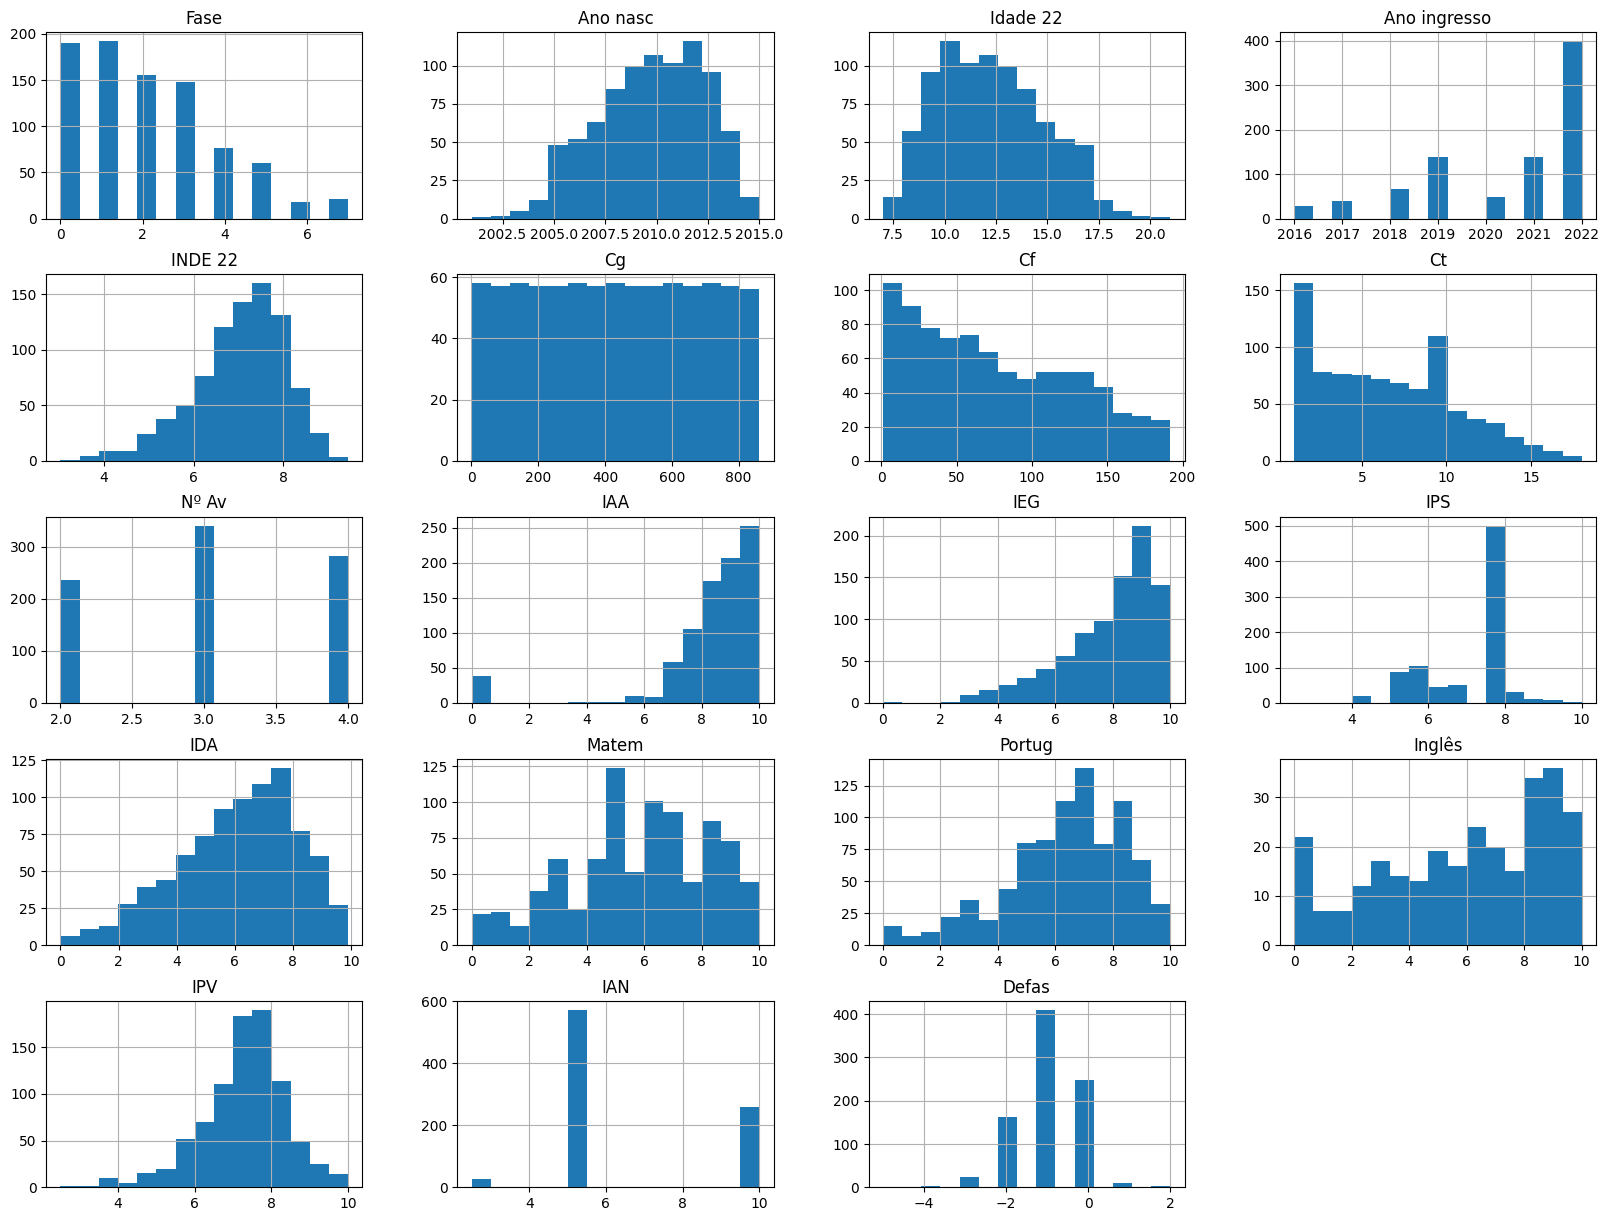

In [ ]:
df_2022.hist(bins=15, figsize=(20,15));

##### **2023**

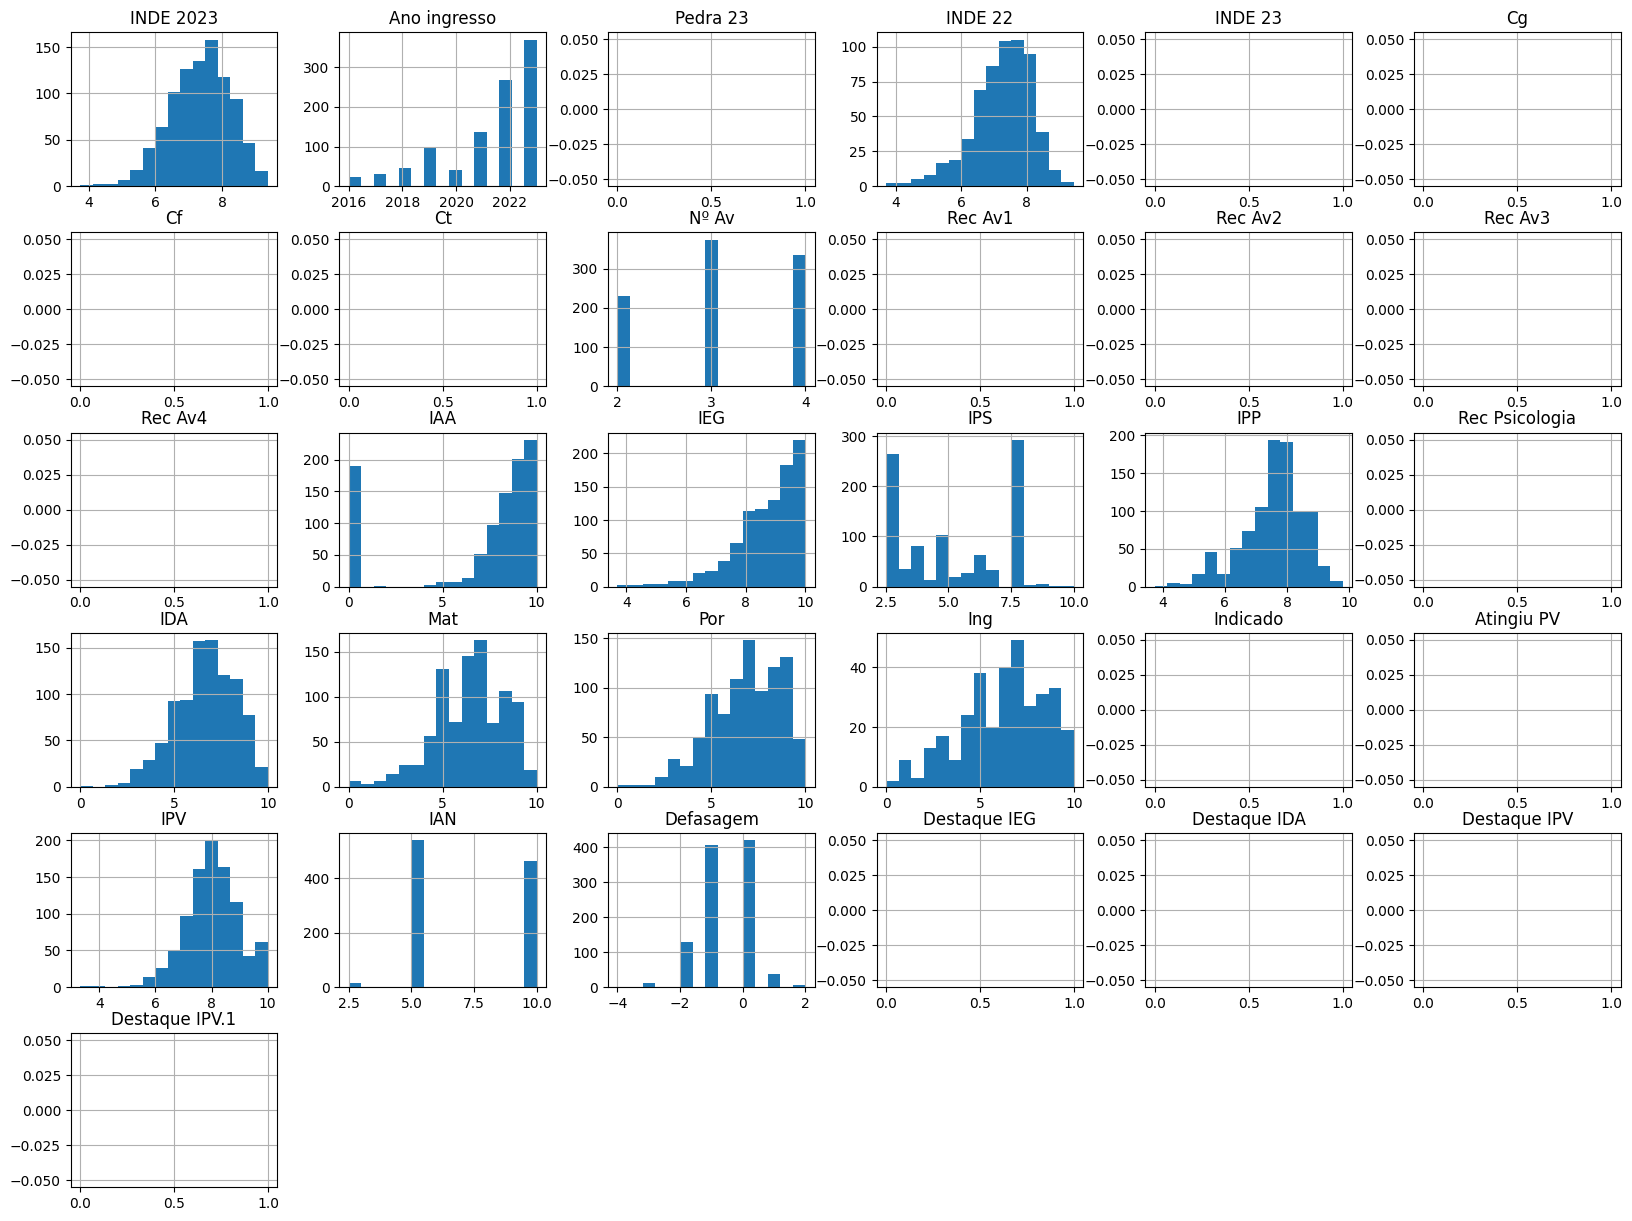

In [ ]:
df_2023.hist(bins=15, figsize=(20,15));

##### **2024**

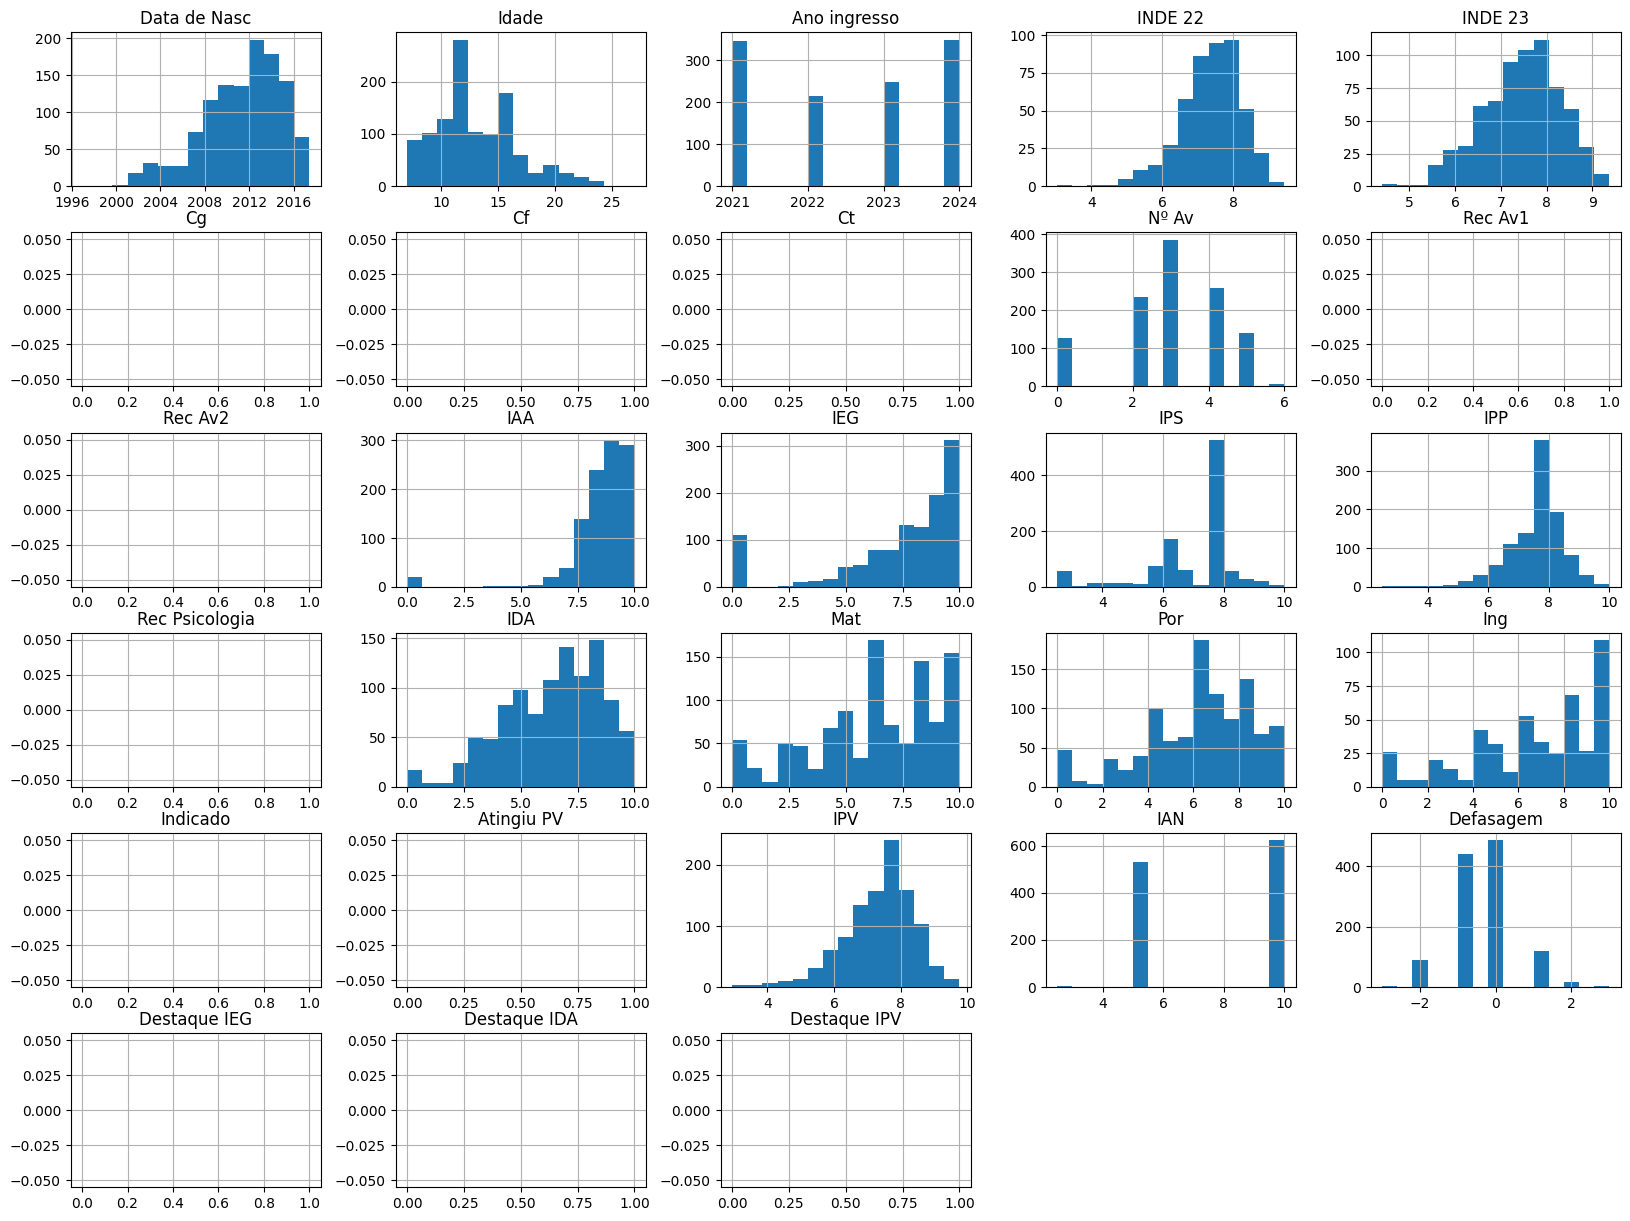

In [ ]:
df_2024.hist(bins=15, figsize=(20,15));

## **Pré-processamento / Preparação dos dados**

### **Remoção de colunas em duplicidade e inconsistentes**

In [ ]:
df_2024.drop(columns='Ativo/ Inativo.1', inplace=True)
df_2023.drop(columns='Destaque IPV.1', inplace=True)
df_2023.drop(columns='Idade', inplace=True)

Avaliando:

In [ ]:
display(df_2024.columns), display(df_2023.columns)

Index(['RA', 'Fase', 'INDE 2024', 'Pedra 2024', 'Turma', 'Nome Anonimizado',
       'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso',
       'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23',
       'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
       'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Avaliador4',
       'Avaliador5', 'Avaliador6', 'IAA', 'IEG', 'IPS', 'IPP',
       'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV',
       'IPV', 'IAN', 'Fase Ideal', 'Defasagem', 'Destaque IEG', 'Destaque IDA',
       'Destaque IPV', 'Escola', 'Ativo/ Inativo'],
      dtype='object')

Index(['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado',
       'Data de Nasc', 'Gênero', 'Ano ingresso', 'Instituição de ensino',
       'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23',
       'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2',
       'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA',
       'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing',
       'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 'Defasagem',
       'Destaque IEG', 'Destaque IDA', 'Destaque IPV'],
      dtype='object')

(None, None)

### **Remoção de registros inválidos e que não são possíveis recuperar nos DataFrames**

In [ ]:
valores_inconsistentes = ['INCLUIR', '#DIV/0!', '#N/A']

df_2022 = df_2022[~df_2022[["INDE 22", "Pedra 22"]].isin(valores_inconsistentes).any(axis=1)]
df_2023 = df_2023[~df_2023[["INDE 2023", "Pedra 2023"]].isin(valores_inconsistentes).any(axis=1)]
df_2024 = df_2024[~df_2024[["INDE 2024", "Pedra 2024"]].isin(valores_inconsistentes).any(axis=1)]

### **Adição da coluna IPP e sua respectivas notas com base no INDE e nos demais índices no DF_2022**

In [ ]:
df_2022['IPP'] = (df_2022['INDE 22'] - ((df_2022['IAN'] * 0.1)+(df_2022['IDA'] * 0.2)+(df_2022['IEG'] * 0.2)+(df_2022['IAA'] * 0.1)+(df_2022['IPS'] * 0.1)+(df_2022['IPV'] * 0.2))) / 0.1

Avaliando:

In [ ]:
df_2022.head()

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV,IPP
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,8.174
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,7.894
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,8.198
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,5.554
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,8.392


### **Correção da coluna IDADE no DF_2023**

In [ ]:
df_2023['Data de Nasc'] = pd.to_datetime(df_2023['Data de Nasc'], errors='coerce')
data_ref = pd.Timestamp('2023-12-31')
df_2023['IDADE'] = (data_ref - df_2023['Data de Nasc']).dt.days // 365

Avaliando:

In [ ]:
df_2023.head()

,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Gênero,Ano ingresso,Instituição de ensino,...,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,IDADE
0,RA-861,ALFA,9.31095,Topázio,ALFA A - G0/G1,Aluno-861,2015-06-17,Feminino,2023,Pública,...,NaN,NaN,8.920,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,8
1,RA-862,ALFA,8.22120,Topázio,ALFA A - G0/G1,Aluno-862,2014-05-31,Masculino,2023,Pública,...,NaN,NaN,8.585,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,9
2,RA-863,ALFA,5.92975,Quartzo,ALFA A - G0/G1,Aluno-863,2016-02-25,Masculino,2023,Pública,...,NaN,NaN,6.260,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,7
3,RA-864,ALFA,7.03400,Ametista,ALFA A - G0/G1,Aluno-864,2015-12-03,Feminino,2023,Pública,...,NaN,NaN,8.500,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,8
4,RA-865,ALFA,8.15520,Topázio,ALFA A - G0/G1,Aluno-865,2014-11-13,Masculino,2023,Pública,...,NaN,NaN,7.915,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,9


### **Função para inserção da variável ANO nos conjuntos**

In [ ]:
def inserir_ano(arquivo_aba):
  for sheet_name, df in arquivo_aba.items():
    ano = ''.join(filter(str.isdigit, sheet_name))
    if ano:
      df['ANO'] = int(ano)
      print(f'Coluna ANO adicionada a partir da aba {sheet_name} com o conteúdo de {ano} ✅')

dfs = {'PEDE2022': df_2022, 'PEDE2023': df_2023, 'PEDE2024': df_2024}

inserir_ano(dfs)

Coluna ANO adicionada a partir da aba PEDE2022 com o conteúdo de 2022 ✅
Coluna ANO adicionada a partir da aba PEDE2023 com o conteúdo de 2023 ✅
Coluna ANO adicionada a partir da aba PEDE2024 com o conteúdo de 2024 ✅


Avaliando:

In [ ]:
df_2022.ANO.head(1), df_2023.ANO.head(1), df_2024.ANO.head(1)

(0    2022
 Name: ANO, dtype: int64,
 0    2023
 Name: ANO, dtype: int64,
 0    2024
 Name: ANO, dtype: int64)

### **Função para alterar as colunas dos conjuntos para maiúscula**

In [ ]:
def colunas_upper(arquivo_aba):
  for sheet_name, df in arquivo_aba.items():
    df.columns = df.columns.str.upper()

colunas_upper(dfs)

Avaliando:

In [ ]:
display(df_2022.columns), display(df_2023.columns),display( df_2024.columns)

Index(['RA', 'FASE', 'TURMA', 'NOME', 'ANO NASC', 'IDADE 22', 'GÊNERO',
       'ANO INGRESSO', 'INSTITUIÇÃO DE ENSINO', 'PEDRA 20', 'PEDRA 21',
       'PEDRA 22', 'INDE 22', 'CG', 'CF', 'CT', 'Nº AV', 'AVALIADOR1',
       'REC AV1', 'AVALIADOR2', 'REC AV2', 'AVALIADOR3', 'REC AV3',
       'AVALIADOR4', 'REC AV4', 'IAA', 'IEG', 'IPS', 'REC PSICOLOGIA', 'IDA',
       'MATEM', 'PORTUG', 'INGLÊS', 'INDICADO', 'ATINGIU PV', 'IPV', 'IAN',
       'FASE IDEAL', 'DEFAS', 'DESTAQUE IEG', 'DESTAQUE IDA', 'DESTAQUE IPV',
       'IPP', 'ANO'],
      dtype='object')

Index(['RA', 'FASE', 'INDE 2023', 'PEDRA 2023', 'TURMA', 'NOME ANONIMIZADO',
       'DATA DE NASC', 'GÊNERO', 'ANO INGRESSO', 'INSTITUIÇÃO DE ENSINO',
       'PEDRA 20', 'PEDRA 21', 'PEDRA 22', 'PEDRA 23', 'INDE 22', 'INDE 23',
       'CG', 'CF', 'CT', 'Nº AV', 'AVALIADOR1', 'REC AV1', 'AVALIADOR2',
       'REC AV2', 'AVALIADOR3', 'REC AV3', 'AVALIADOR4', 'REC AV4', 'IAA',
       'IEG', 'IPS', 'IPP', 'REC PSICOLOGIA', 'IDA', 'MAT', 'POR', 'ING',
       'INDICADO', 'ATINGIU PV', 'IPV', 'IAN', 'FASE IDEAL', 'DEFASAGEM',
       'DESTAQUE IEG', 'DESTAQUE IDA', 'DESTAQUE IPV', 'IDADE', 'ANO'],
      dtype='object')

Index(['RA', 'FASE', 'INDE 2024', 'PEDRA 2024', 'TURMA', 'NOME ANONIMIZADO',
       'DATA DE NASC', 'IDADE', 'GÊNERO', 'ANO INGRESSO',
       'INSTITUIÇÃO DE ENSINO', 'PEDRA 20', 'PEDRA 21', 'PEDRA 22', 'PEDRA 23',
       'INDE 22', 'INDE 23', 'CG', 'CF', 'CT', 'Nº AV', 'AVALIADOR1',
       'REC AV1', 'AVALIADOR2', 'REC AV2', 'AVALIADOR3', 'AVALIADOR4',
       'AVALIADOR5', 'AVALIADOR6', 'IAA', 'IEG', 'IPS', 'IPP',
       'REC PSICOLOGIA', 'IDA', 'MAT', 'POR', 'ING', 'INDICADO', 'ATINGIU PV',
       'IPV', 'IAN', 'FASE IDEAL', 'DEFASAGEM', 'DESTAQUE IEG', 'DESTAQUE IDA',
       'DESTAQUE IPV', 'ESCOLA', 'ATIVO/ INATIVO', 'ANO'],
      dtype='object')

(None, None, None)

### **Função para remover a acentuação das colunas**

In [ ]:
def remover_acentos(arquivo_aba):
    for sheet_name, df in arquivo_aba.items():
        df.columns = df.columns.str.normalize('NFKD').str.encode('ASCII', 'ignore').str.decode('utf-8')

dfs = {'PEDE2022': df_2022, 'PEDE2023': df_2023, 'PEDE2024': df_2024}

remover_acentos(dfs)

In [ ]:
df_2022.columns, df_2023.columns, df_2024.columns

(Index(['RA', 'FASE', 'TURMA', 'NOME', 'ANO NASC', 'IDADE 22', 'GENERO',
        'ANO INGRESSO', 'INSTITUICAO DE ENSINO', 'PEDRA 20', 'PEDRA 21',
        'PEDRA 22', 'INDE 22', 'CG', 'CF', 'CT', 'No AV', 'AVALIADOR1',
        'REC AV1', 'AVALIADOR2', 'REC AV2', 'AVALIADOR3', 'REC AV3',
        'AVALIADOR4', 'REC AV4', 'IAA', 'IEG', 'IPS', 'REC PSICOLOGIA', 'IDA',
        'MATEM', 'PORTUG', 'INGLES', 'INDICADO', 'ATINGIU PV', 'IPV', 'IAN',
        'FASE IDEAL', 'DEFAS', 'DESTAQUE IEG', 'DESTAQUE IDA', 'DESTAQUE IPV',
        'IPP', 'ANO'],
       dtype='object'),
 Index(['RA', 'FASE', 'INDE 2023', 'PEDRA 2023', 'TURMA', 'NOME ANONIMIZADO',
        'DATA DE NASC', 'GENERO', 'ANO INGRESSO', 'INSTITUICAO DE ENSINO',
        'PEDRA 20', 'PEDRA 21', 'PEDRA 22', 'PEDRA 23', 'INDE 22', 'INDE 23',
        'CG', 'CF', 'CT', 'No AV', 'AVALIADOR1', 'REC AV1', 'AVALIADOR2',
        'REC AV2', 'AVALIADOR3', 'REC AV3', 'AVALIADOR4', 'REC AV4', 'IAA',
        'IEG', 'IPS', 'IPP', 'REC PSICOLOGIA', 'ID

### **Função para substituir espaço por _ no nome das variáveis**

In [ ]:
dfs = [df_2022, df_2023, df_2024]

for df in dfs:
    df.columns = df.columns.str.replace(" ", "_")

Avaliando:

In [ ]:
df_2022.columns, df_2023.columns, df_2024.columns

(Index(['RA', 'FASE', 'TURMA', 'NOME', 'ANO_NASC', 'IDADE_22', 'GENERO',
        'ANO_INGRESSO', 'INSTITUICAO_DE_ENSINO', 'PEDRA_20', 'PEDRA_21',
        'PEDRA_22', 'INDE_22', 'CG', 'CF', 'CT', 'No_AV', 'AVALIADOR1',
        'REC_AV1', 'AVALIADOR2', 'REC_AV2', 'AVALIADOR3', 'REC_AV3',
        'AVALIADOR4', 'REC_AV4', 'IAA', 'IEG', 'IPS', 'REC_PSICOLOGIA', 'IDA',
        'MATEM', 'PORTUG', 'INGLES', 'INDICADO', 'ATINGIU_PV', 'IPV', 'IAN',
        'FASE_IDEAL', 'DEFAS', 'DESTAQUE_IEG', 'DESTAQUE_IDA', 'DESTAQUE_IPV',
        'IPP', 'ANO'],
       dtype='object'),
 Index(['RA', 'FASE', 'INDE_2023', 'PEDRA_2023', 'TURMA', 'NOME_ANONIMIZADO',
        'DATA_DE_NASC', 'GENERO', 'ANO_INGRESSO', 'INSTITUICAO_DE_ENSINO',
        'PEDRA_20', 'PEDRA_21', 'PEDRA_22', 'PEDRA_23', 'INDE_22', 'INDE_23',
        'CG', 'CF', 'CT', 'No_AV', 'AVALIADOR1', 'REC_AV1', 'AVALIADOR2',
        'REC_AV2', 'AVALIADOR3', 'REC_AV3', 'AVALIADOR4', 'REC_AV4', 'IAA',
        'IEG', 'IPS', 'IPP', 'REC_PSICOLOGIA', 'ID

### **Atualizando nome das colunas para padronização**

In [ ]:
df_2022.rename(columns={'IDADE_22':'IDADE', 'DEFAS':'DEFASAGEM', 'PEDRA_22': 'PEDRA', 'INDE_22':'INDE'}, inplace=True)
print('Colunas renomeadas para o dataframe com ANO 2022 ✅')
df_2023.rename(columns={'PEDRA_2023': 'PEDRA', 'INDE_2023':'INDE'}, inplace=True)
print('Colunas renomeadas para o dataframe com ANO 2023 ✅')
df_2024.rename(columns={'PEDRA_2024': 'PEDRA', 'INDE_2024':'INDE'}, inplace=True)
print('Colunas renomeadas para o dataframe com ANO 2024 ✅')

Colunas renomeadas para o dataframe com ANO 2022 ✅
Colunas renomeadas para o dataframe com ANO 2023 ✅
Colunas renomeadas para o dataframe com ANO 2024 ✅


Avaliando:

In [ ]:
df_2022.columns, df_2023.columns, df_2024.columns

(Index(['RA', 'FASE', 'TURMA', 'NOME', 'ANO_NASC', 'IDADE', 'GENERO',
        'ANO_INGRESSO', 'INSTITUICAO_DE_ENSINO', 'PEDRA_20', 'PEDRA_21',
        'PEDRA', 'INDE', 'CG', 'CF', 'CT', 'No_AV', 'AVALIADOR1', 'REC_AV1',
        'AVALIADOR2', 'REC_AV2', 'AVALIADOR3', 'REC_AV3', 'AVALIADOR4',
        'REC_AV4', 'IAA', 'IEG', 'IPS', 'REC_PSICOLOGIA', 'IDA', 'MATEM',
        'PORTUG', 'INGLES', 'INDICADO', 'ATINGIU_PV', 'IPV', 'IAN',
        'FASE_IDEAL', 'DEFASAGEM', 'DESTAQUE_IEG', 'DESTAQUE_IDA',
        'DESTAQUE_IPV', 'IPP', 'ANO'],
       dtype='object'),
 Index(['RA', 'FASE', 'INDE', 'PEDRA', 'TURMA', 'NOME_ANONIMIZADO',
        'DATA_DE_NASC', 'GENERO', 'ANO_INGRESSO', 'INSTITUICAO_DE_ENSINO',
        'PEDRA_20', 'PEDRA_21', 'PEDRA_22', 'PEDRA_23', 'INDE_22', 'INDE_23',
        'CG', 'CF', 'CT', 'No_AV', 'AVALIADOR1', 'REC_AV1', 'AVALIADOR2',
        'REC_AV2', 'AVALIADOR3', 'REC_AV3', 'AVALIADOR4', 'REC_AV4', 'IAA',
        'IEG', 'IPS', 'IPP', 'REC_PSICOLOGIA', 'IDA', 'MAT', 'POR

### **Dataset Único**

In [ ]:
# Certificando que a coluna INDE seja numérica em cada DF de origem antes da concatenação para uso futuro do Machine Learning

df_2022['INDE'] = pd.to_numeric(df_2022['INDE'], errors='coerce')
df_2023['INDE'] = pd.to_numeric(df_2023['INDE'], errors='coerce')
df_2024['INDE'] = pd.to_numeric(df_2024['INDE'], errors='coerce')

df_completo = pd.concat([df_2022[['ANO','RA', 'IDADE','GENERO', 'ANO_INGRESSO', 'FASE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'ATINGIU_PV', 'INDE', 'PEDRA', 'DEFASAGEM']],
                         df_2023[['ANO','RA', 'IDADE','GENERO', 'ANO_INGRESSO', 'FASE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'ATINGIU_PV', 'INDE', 'PEDRA', 'DEFASAGEM']],
                         df_2024[['ANO','RA', 'IDADE','GENERO', 'ANO_INGRESSO', 'FASE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'ATINGIU_PV', 'INDE', 'PEDRA', 'DEFASAGEM']]],
                         ignore_index=True)

In [ ]:
df_completo.head()

,ANO,RA,IDADE,GENERO,ANO_INGRESSO,FASE,IAN,IDA,IEG,IAA,IPS,IPP,IPV,ATINGIU_PV,INDE,PEDRA,DEFASAGEM
0,2022,RA-1,19,Menina,2016,7,5.0,4.0,4.1,8.3,5.6,8.174,7.278,Não,5.783,Quartzo,-1
1,2022,RA-2,17,Menina,2017,7,10.0,6.8,5.2,8.8,6.3,7.894,6.778,Não,7.055,Ametista,0
2,2022,RA-3,17,Menina,2016,7,10.0,5.6,7.9,0.0,5.6,8.198,7.556,Não,6.591,Ágata,0
3,2022,RA-4,17,Menino,2017,7,10.0,5.0,4.5,8.8,5.6,5.554,5.278,Não,5.951,Quartzo,0
4,2022,RA-5,17,Menina,2016,7,10.0,5.2,8.6,7.9,5.6,8.392,7.389,Não,7.427,Ametista,0


In [ ]:
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2992 entries, 0 to 2991
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ANO           2992 non-null   int64  
 1   RA            2992 non-null   object 
 2   IDADE         2992 non-null   int64  
 3   GENERO        2992 non-null   object 
 4   ANO_INGRESSO  2992 non-null   int64  
 5   FASE          2992 non-null   object 
 6   IAN           2992 non-null   float64
 7   IDA           2852 non-null   float64
 8   IEG           2916 non-null   float64
 9   IAA           2865 non-null   float64
 10  IPS           2859 non-null   float64
 11  IPP           2852 non-null   float64
 12  IPV           2852 non-null   float64
 13  ATINGIU_PV    860 non-null    object 
 14  INDE          2845 non-null   float64
 15  PEDRA         2845 non-null   object 
 16  DEFASAGEM     2992 non-null   int64  
dtypes: float64(8), int64(4), object(5)
memory usage: 397.5+ KB


## **Análise exploratória dos dados**

### **Variável RA**

In [ ]:
df_completo.RA.value_counts()

,count
RA,
RA-860,3
RA-859,3
RA-858,3
RA-855,3
RA-854,3
...,...
RA-1623,1
RA-1589,1
RA-1590,1


### **Variável ANO**

In [ ]:
df_completo.ANO.unique()

array([2022, 2023, 2024])

In [ ]:
ano_pct = df_completo.ANO.value_counts(normalize=True).sort_values(ascending=False)*100
ano = df_completo.ANO.value_counts().sort_values(ascending=False)

visao_ano = pd.DataFrame({'ANO': ano.index, 'CONTAGEM': ano.values, 'PERCENTUAL': ano_pct.values})
visao_ano['PERCENTUAL'] = visao_ano['PERCENTUAL'].round(2)
visao_ano

,ANO,CONTAGEM,PERCENTUAL
0,2024,1118,37.37
1,2023,1014,33.89
2,2022,860,28.74


### **Variável ANO_INGRESSO**

In [ ]:
display(np.sort(df_completo.ANO_INGRESSO.unique()))

array([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [ ]:
ano_ingresso_pct = df_completo.ANO_INGRESSO.value_counts(normalize=True).sort_values(ascending=False)*100
ano_ingresso = df_completo.ANO_INGRESSO.value_counts().sort_values(ascending=False)

visao_ano_ingresso = pd.DataFrame({'ANO_INGRESSO': ano_ingresso.index, 'CONTAGEM': ano_ingresso.values, 'PERCENTUAL': ano_ingresso_pct.values})
visao_ano_ingresso = visao_ano_ingresso.sort_values('ANO_INGRESSO')
visao_ano_ingresso['PERCENTUAL'] = visao_ano_ingresso['PERCENTUAL'].round(2)
visao_ano_ingresso

,ANO_INGRESSO,CONTAGEM,PERCENTUAL
8,2016,53,1.77
7,2017,72,2.41
5,2018,113,3.78
4,2019,237,7.92
6,2020,88,2.94
2,2021,583,19.49
0,2022,880,29.41
1,2023,617,20.62
3,2024,349,11.66


### **Variável IDADE**

In [ ]:
display(np.sort(df_completo.IDADE.unique()))

array([ 7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
       24, 25, 27])

In [ ]:
df_completo.IDADE.describe()

,IDADE
count,2992.000000
mean,12.469920
std,3.149634
min,7.000000
25%,10.000000
50%,12.000000
75%,15.000000
max,27.000000


In [ ]:
idade_pct = df_completo.IDADE.value_counts(normalize=True).sort_values(ascending=False)*100
idade = df_completo.IDADE.value_counts().sort_values(ascending=False)

visao_idade = pd.DataFrame({'IDADE': idade.index, 'CONTAGEM': idade.values, 'PERCENTUAL': idade_pct.values})
visao_idade = visao_idade.sort_values('IDADE')
visao_idade['PERCENTUAL'] = visao_idade['PERCENTUAL'].round(2)
visao_idade

,IDADE,CONTAGEM,PERCENTUAL
11,7,45,1.50
7,8,218,7.29
4,9,300,10.03
2,10,353,11.80
0,11,367,12.27
1,12,362,12.10
3,13,310,10.36
5,14,277,9.26
6,15,227,7.59
8,16,193,6.45


In [ ]:
df_completo.groupby('ANO')['IDADE'].mean()

,IDADE
ANO,
2022,12.138372
2023,12.510848
2024,12.687835


### **Variável GENERO**

In [ ]:
df_completo.GENERO.unique()

array(['Menina', 'Menino', 'Feminino', 'Masculino'], dtype=object)

In [ ]:
df_completo.GENERO.replace({'Menina':'Feminino', 'Menino':'Masculino'}, inplace=True)
df_completo.GENERO.unique()

/tmp/ipykernel_5494/1579360266.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_completo.GENERO.replace({'Menina':'Feminino', 'Menino':'Masculino'}, inplace=True)


array(['Feminino', 'Masculino'], dtype=object)

In [ ]:
df_completo.GENERO.describe()

,GENERO
count,2992
unique,2
top,Feminino
freq,1613


In [ ]:
genero_pct = df_completo.GENERO.value_counts(normalize=True).sort_values(ascending=False)*100
genero = df_completo.GENERO.value_counts().sort_values(ascending=False)

visao_genero = pd.DataFrame({'GENERO': genero.index, 'CONTAGEM': genero.values, 'PERCENTUAL': genero_pct.values})
visao_genero['PERCENTUAL'] = visao_genero['PERCENTUAL'].round(2)
visao_genero


,GENERO,CONTAGEM,PERCENTUAL
0,Feminino,1613,53.91
1,Masculino,1379,46.09


In [ ]:
df_completo.groupby(['ANO', 'GENERO'])['GENERO'].value_counts()

ANO   GENERO   
2022  Feminino     457
      Masculino    403
2023  Feminino     546
      Masculino    468
2024  Feminino     610
      Masculino    508
Name: count, dtype: int64

### **Variável FASE**

In [ ]:
df_completo.FASE.unique()

array([7, 6, 5, 4, 3, 2, 1, 0, 'ALFA', 'FASE 1', 'FASE 2', 'FASE 3',
       'FASE 4', 'FASE 5', 'FASE 6', 'FASE 7', 'FASE 8', '1A', '1B', '1C',
       '1D', '1E', '1G', '1H', '1J', '1K', '1L', '1M', '1N', '1P', '1R',
       '2A', '2B', '2C', '2D', '2G', '2H', '2I', '2K', '2L', '2M', '2N',
       '2P', '2R', '2U', '3A', '3B', '3C', '3D', '3F', '3G', '3H', '3I',
       '3K', '3L', '3M', '3N', '3P', '3R', '3U', '4A', '4B', '4C', '4F',
       '4H', '4L', '4M', '4N', '4R', '5A', '5B', '5C', '5D', '5F', '5G',
       '5L', '5M', '5N', '6A', '6L', '7A', '7E', '8A', '8B', '8D', '8E',
       '8F'], dtype=object)

In [ ]:
def padronizar_fase(fase):
    fase_str = str(fase).strip().upper()

    if 'ALFA' in fase_str:
        return 0

    numeros = re.findall(r'\d+', fase_str)
    if numeros:
        return int(numeros[0])

    return fase

df_completo['FASE'] = df_completo['FASE'].apply(padronizar_fase)

In [ ]:
df_completo.FASE.unique()

array([7, 6, 5, 4, 3, 2, 1, 0, 8])

In [ ]:
df_completo.FASE.replace({0:'ALFA',
                          1:'FASE 1',
                          2:'FASE 2',
                          3:'FASE 3',
                          4:'FASE 4',
                          5:'FASE 5',
                          6:'FASE 6',
                          7:'FASE 7',
                          8:'FASE 8',
                          9:'FASE 9'
                          }, inplace=True)

/tmp/ipykernel_5494/3160511917.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_completo.FASE.replace({0:'ALFA',


In [ ]:
df_completo.FASE.unique()

array(['FASE 7', 'FASE 6', 'FASE 5', 'FASE 4', 'FASE 3', 'FASE 2',
       'FASE 1', 'ALFA', 'FASE 8'], dtype=object)

### **Variável PEDRA**

In [ ]:
df_completo.PEDRA.unique()

array(['Quartzo', 'Ametista', 'Ágata', 'Topázio', 'Agata', nan],
      dtype=object)

In [ ]:
df_completo.PEDRA.replace({'Agata':'Ágata'}, inplace=True)
df_completo.PEDRA.unique()

/tmp/ipykernel_5494/2077446869.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_completo.PEDRA.replace({'Agata':'Ágata'}, inplace=True)


array(['Quartzo', 'Ametista', 'Ágata', 'Topázio', nan], dtype=object)

In [ ]:
df_completo.PEDRA.value_counts()

,count
PEDRA,
Ametista,1120
Ágata,721
Topázio,688
Quartzo,316


In [ ]:
df_completo.PEDRA.unique()

array(['Quartzo', 'Ametista', 'Ágata', 'Topázio', nan], dtype=object)

## **Desafio - Dores do Negócio**

#### **Q1. Adequação do nível (IAN):**
Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano? (Ex.: quantos alunos estão moderadamente ou severamente defasados?)

In [ ]:
cols = ['ANO', 'DEFASAGEM', 'IAN']
df_total_ian = df_completo[cols]

df_total_ian.head()

,ANO,DEFASAGEM,IAN
0,2022,-1,5.0
1,2022,0,10.0
2,2022,0,10.0
3,2022,0,10.0
4,2022,0,10.0


/tmp/ipykernel_5494/1250631511.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total_ian['PERFIL_IAN'] = df_total_ian['DEFASAGEM'].apply(classificar_defasagem)


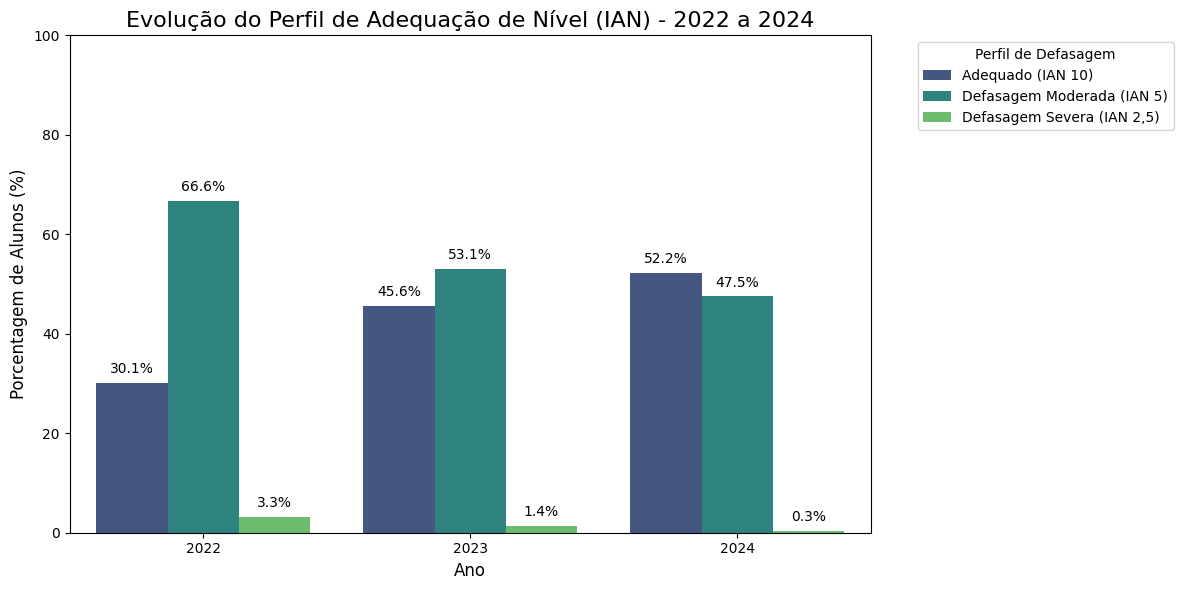


--- Tabela Resumo: Evolução do Perfil IAN ---


,ANO,PERFIL_IAN,CONTAGEM,PORCENTAGEM
0,2022,Adequado (IAN 10),259,30.116279
1,2022,Defasagem Moderada (IAN 5),573,66.627907
2,2022,"Defasagem Severa (IAN 2,5)",28,3.255814
3,2023,Adequado (IAN 10),462,45.562130
4,2023,Defasagem Moderada (IAN 5),538,53.057199
5,2023,"Defasagem Severa (IAN 2,5)",14,1.380671
6,2024,Adequado (IAN 10),584,52.236136
7,2024,Defasagem Moderada (IAN 5),531,47.495528
8,2024,"Defasagem Severa (IAN 2,5)",3,0.268336


In [ ]:
def classificar_defasagem(valor):
    if valor >= 0:
        return 'Adequado (IAN 10)'
    elif valor >= -2:
        return 'Defasagem Moderada (IAN 5)'
    else:
        return 'Defasagem Severa (IAN 2,5)'

df_total_ian['PERFIL_IAN'] = df_total_ian['DEFASAGEM'].apply(classificar_defasagem)

perfil_counts = df_total_ian.groupby(['ANO', 'PERFIL_IAN']).size().reset_index(name='CONTAGEM')


total_por_ano = df_total_ian.groupby('ANO').size().reset_index(name='TOTAL')
perfil_counts = pd.merge(perfil_counts, total_por_ano, on='ANO')
perfil_counts['PORCENTAGEM'] = (perfil_counts['CONTAGEM'] / perfil_counts['TOTAL']) * 100


plt.figure(figsize=(12, 6))
grafico = sns.barplot(
    data=perfil_counts,
    x='ANO',
    y='PORCENTAGEM',
    hue='PERFIL_IAN',
    palette='viridis'
)

plt.title('Evolução do Perfil de Adequação de Nível (IAN) - 2022 a 2024', fontsize=16)
plt.ylabel('Porcentagem de Alunos (%)', fontsize=12)
plt.xlabel('Ano', fontsize=12)
plt.legend(title='Perfil de Defasagem', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 100)


for p in grafico.patches:
    height = p.get_height()
    if height > 0:
        grafico.annotate(f'{height:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                        textcoords='offset points')

plt.tight_layout()
plt.show();

print("\n--- Tabela Resumo: Evolução do Perfil IAN ---")
display(perfil_counts[['ANO', 'PERFIL_IAN', 'CONTAGEM', 'PORCENTAGEM']].sort_values(['ANO', 'PERFIL_IAN']));

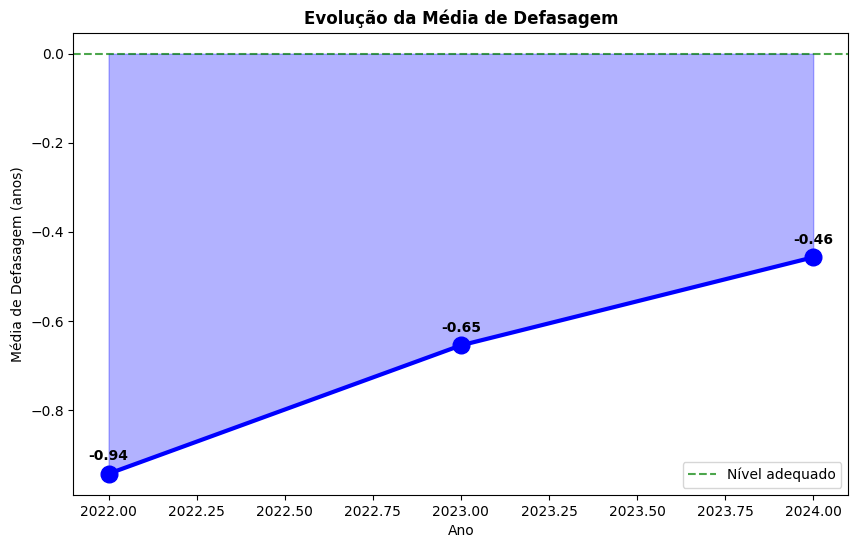

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

media_def = df_completo.groupby('ANO')['DEFASAGEM'].mean()

# Plotando no eixo 'ax'
ax.plot(media_def.index, media_def.values, marker='o', linewidth=3, markersize=12, color='blue')
ax.fill_between(media_def.index, media_def.values, alpha=0.3, color='blue')
ax.axhline(y=0, color='green', linestyle='--', alpha=0.7, label='Nível adequado')

ax.set_title('Evolução da Média de Defasagem', fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Média de Defasagem (anos)')

for x, y in zip(media_def.index, media_def.values):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontweight='bold')

ax.legend()
plt.show()

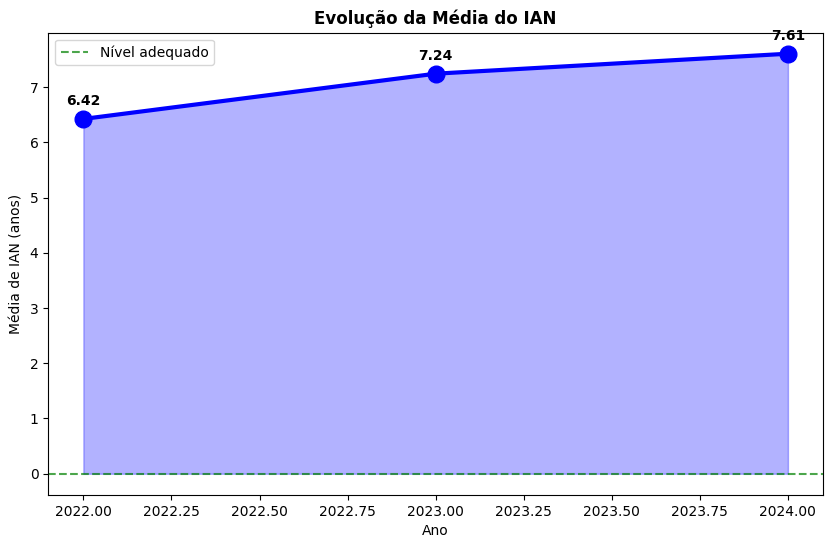

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

media_def = df_completo.groupby('ANO')['IAN'].mean()

# Plotando no eixo 'ax'
ax.plot(media_def.index, media_def.values, marker='o', linewidth=3, markersize=12, color='blue')
ax.fill_between(media_def.index, media_def.values, alpha=0.3, color='blue')
ax.axhline(y=0, color='green', linestyle='--', alpha=0.7, label='Nível adequado')

ax.set_title('Evolução da Média do IAN', fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Média de IAN (anos)')

for x, y in zip(media_def.index, media_def.values):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontweight='bold')

ax.legend()
plt.show()

R1. O perfil de defasagem dos alunos por ano:
- 2022: Defasagem moderada (66,6%).
- 2023: Defasagem moderada (53,1%).
- 2024: Adequado (52,2%).

O perfil de defasagem veio melhorando ao longo do tempo e para embasar um pouco mais a análise, foi extraído a média de defasagem por ano e a média do IAN por ano.

**Média de defasagem**
- 2022: -0,94.
- 2023: -0,65.
- 2024: -0,46.

De 2022 para 2024, a média foi de -0,94 para -0,41. Uma MELHORIA de 0.53, o que demonstra que ao longo dos anos o perfil vem melhorando.

**IAN médio**
- 2022: 6,42.
- 2023: 7,24.
- 2024: 7,61

Comprovado também pela adequação ao nível crescendo (IAN).

#### **Q2. Desempenho acadêmico (IDA):**
O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

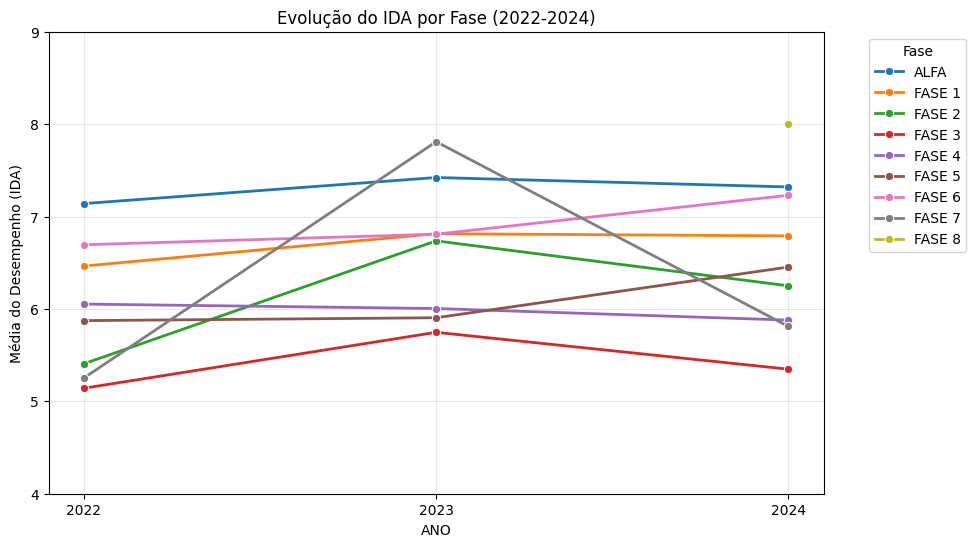

In [ ]:
df_grafico = df_completo.groupby(['ANO', 'FASE'])['IDA'].mean().reset_index()

fases_foco = ['ALFA', 'FASE 1', 'FASE 2', 'FASE 3', 'FASE 4', 'FASE 5', 'FASE 6', 'FASE 7', 'FASE 8', 'FASE 9']
df_grafico = df_grafico[df_grafico['FASE'].isin(fases_foco)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_grafico, x='ANO', y='IDA', hue='FASE', marker='o', linewidth=2)
plt.title('Evolução do IDA por Fase (2022-2024)')
plt.ylabel('Média do Desempenho (IDA)')
plt.xticks([2022, 2023, 2024])
plt.ylim(4, 9)
plt.grid(True, alpha=0.3)
plt.legend(title='Fase', bbox_to_anchor=(1.05, 1))
plt.show()

In [ ]:
df_completo.groupby('ANO')['IDA'].agg(('mean', 'std', 'median')).round(3)

,mean,std,median
ANO,,,
2022,6.093,2.046,6.30
2023,6.663,1.595,6.80
2024,6.351,2.132,6.75


/tmp/ipykernel_5494/1801533450.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


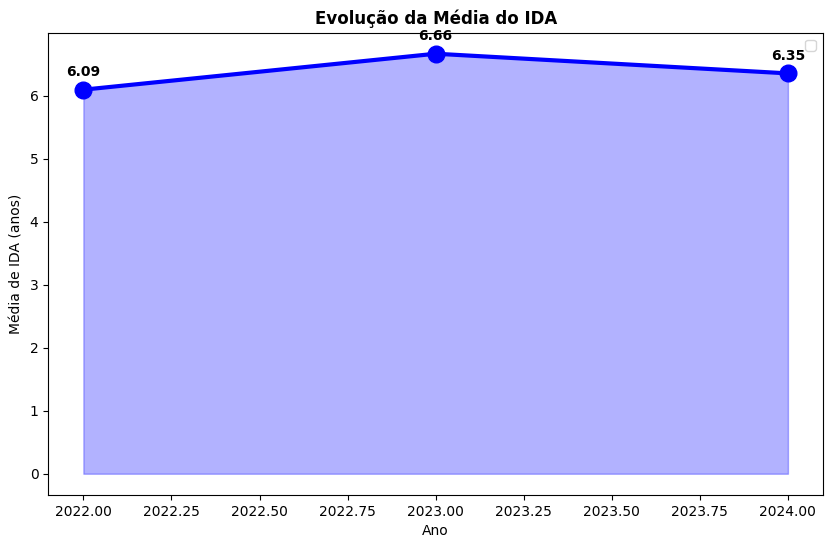

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

media_def = df_completo.groupby('ANO')['IDA'].mean()

ax.plot(media_def.index, media_def.values, marker='o', linewidth=3, markersize=12, color='blue')
ax.fill_between(media_def.index, media_def.values, alpha=0.3, color='blue')

ax.set_title('Evolução da Média do IDA', fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Média de IDA (anos)')

for x, y in zip(media_def.index, media_def.values):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontweight='bold')

ax.legend()
plt.show();

In [ ]:
delta_2022_2024 = (df_completo.groupby('ANO')['IDA'].agg(('mean')).round(3).loc[2022] - df_completo.groupby('ANO')['IDA'].agg(('mean')).round(3).loc[2024]) / df_completo.groupby('ANO')['IDA'].agg(('mean')).round(3).loc[2022] * 100 * (-1)

print(f'Variação entre 2022 e 2024 foi de {delta_2022_2024:.2f}%.')

Variação entre 2022 e 2024 foi de 4.23%.


R2. O desempenho acadêmico média (IDA) está 'EQUILIBRADO':

- 2022: 6.09
- 2023: 6.66
- 2024: 6.35

Tivemos uma melhora na média de 2022 para os anos seguintes. E uma variação de 4.2% entre 2022 e 2024 mantendo-se na média 6.

#### **Q3. Engajamento nas atividades (IEG):**
O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e
do ponto de virada (IPV)?

In [ ]:
df_completo[['IDA', 'INDE', 'IAA', 'IPS', 'IPP', 'IAN', 'IPV','IEG']].corr()['IEG'].head(7).sort_values(ascending=False).round(3)

,IEG
INDE,0.745
IPV,0.558
IDA,0.539
IPP,0.287
IAA,0.133
IAN,-0.006
IPS,-0.046


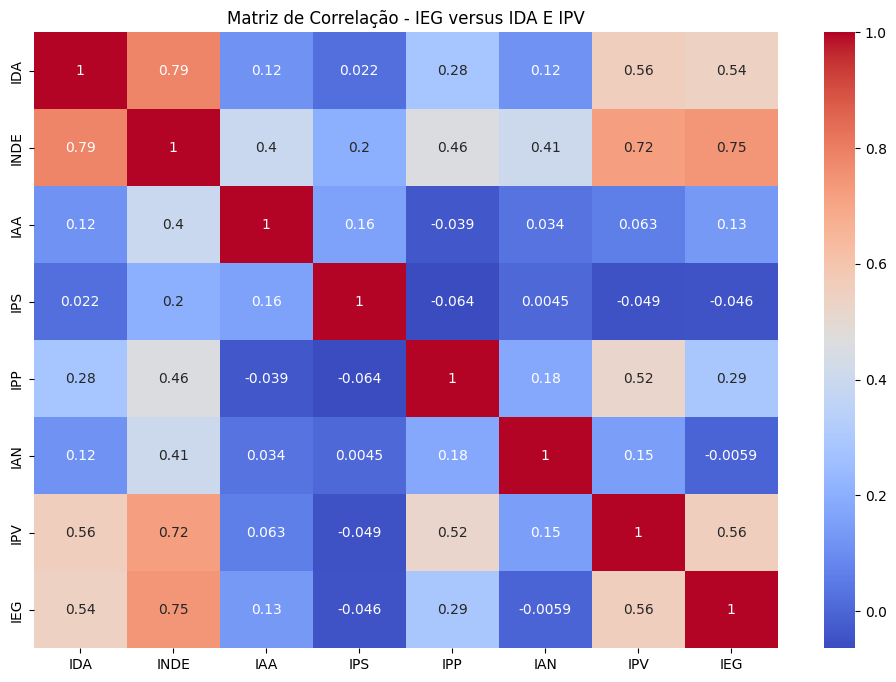

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_completo[['IDA', 'INDE', 'IAA', 'IPS', 'IPP', 'IAN', 'IPV','IEG']].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação - IEG versus IDA E IPV')
plt.show()

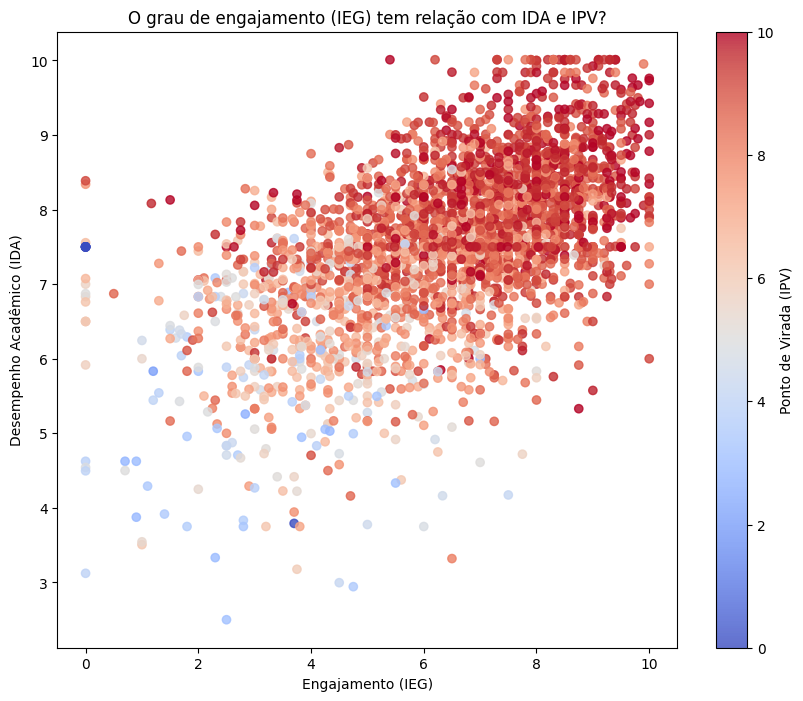

In [ ]:
df_plot = df_completo[['IEG', 'IDA', 'IPV']].dropna()

fig = plt.figure(figsize=(10, 8))

sc = plt.scatter(df_plot['IDA'], df_plot['IPV'], c=df_plot['IEG'], cmap='coolwarm', alpha=0.8)

plt.xlabel('Engajamento (IEG)')
plt.ylabel('Desempenho Acadêmico (IDA)')
plt.title('O grau de engajamento (IEG) tem relação com IDA e IPV?')

plt.colorbar(sc, label='Ponto de Virada (IPV)')

plt.show();


R3. Desempenho do (IEG) na relação com os (IPV) E (IDA):

- IEG vs IDA: 0.539 - Correlação fortemente moderada.
- IEG vs IPV: 0.558 - Correlação fortemente moderada.

Sim, o Engajamento tem ligação direta com o desempenho acadêmico e com o ponto de virada. Logo, podemos compreender que alunos que são mais engajados no processo vão ter um desempenho acadêmico melhor e uma possibilidade maior de atingir o ponto de virada.

#### **Q4. Autoavaliação (IAA):**
As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

In [ ]:
def autoavaliacao(df):
    df_copy = df_completo.copy()
    col_iaa = [c for c in df_copy.columns if c.upper() == 'IAA'][0]
    col_ida = [c for c in df_copy.columns if c.upper() == 'IDA'][0]
    col_fase = [c for c in df_copy.columns if c.upper() == 'FASE'][0]

    df_copy['IAA'] = pd.to_numeric(df_copy[col_iaa], errors='coerce')
    df_copy['IDA'] = pd.to_numeric(df_copy[col_ida], errors='coerce')
    df_copy = df_copy.dropna(subset=['IAA', 'IDA'])

    def categorizar_ciclo(fase):
        fase = str(fase).upper()
        if 'ALFA' in fase: return '1. Alfabetização'
        if any(x in fase for x in ['1', '2', '3', '4', '5']): return '2. Ensino Fundamental'
        return '3. Ensino Médio / Univ.'

    df_copy['Ciclo'] = df_copy[col_fase].apply(categorizar_ciclo)

    df_resumo = df_copy.groupby('Ciclo')[['IAA', 'IDA']].mean().reset_index()
    df_plot = df_resumo.melt(id_vars='Ciclo', value_vars=['IAA', 'IDA'],
                             var_name='Indicador', value_name='Nota')
    return df_plot

df_p4_plot = autoavaliacao(df_2024)

fig4 = px.bar(df_p4_plot, x='Ciclo', y='Nota', color='Indicador',
             barmode='group', text_auto='.1f',
             title='Expectativa (IAA) vs Realidade (IDA) por Ciclo de Aprendizado',
             color_discrete_map={'IAA': '#5D3FD3', 'IDA': '#FFBF00'})

fig4.update_layout(template="plotly_white", yaxis_range=[0,11])
fig4.show()

R4. Os alunos tendem a se autoavaliar de forma muito positiva (médias de IAA frequentemente acima de 9.0), enquanto o desempenho acadêmico real (IDA) apresenta uma média menor e mais oscilante (geralmente entre 6.0 e 7.5). Isso indica que o aluno se sente motivado e pertencente, mas nem sempre consegue traduzir esse sentimento em domínio técnico imediato.

#### **Q5. Aspectos psicossociais (IPS):**
Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

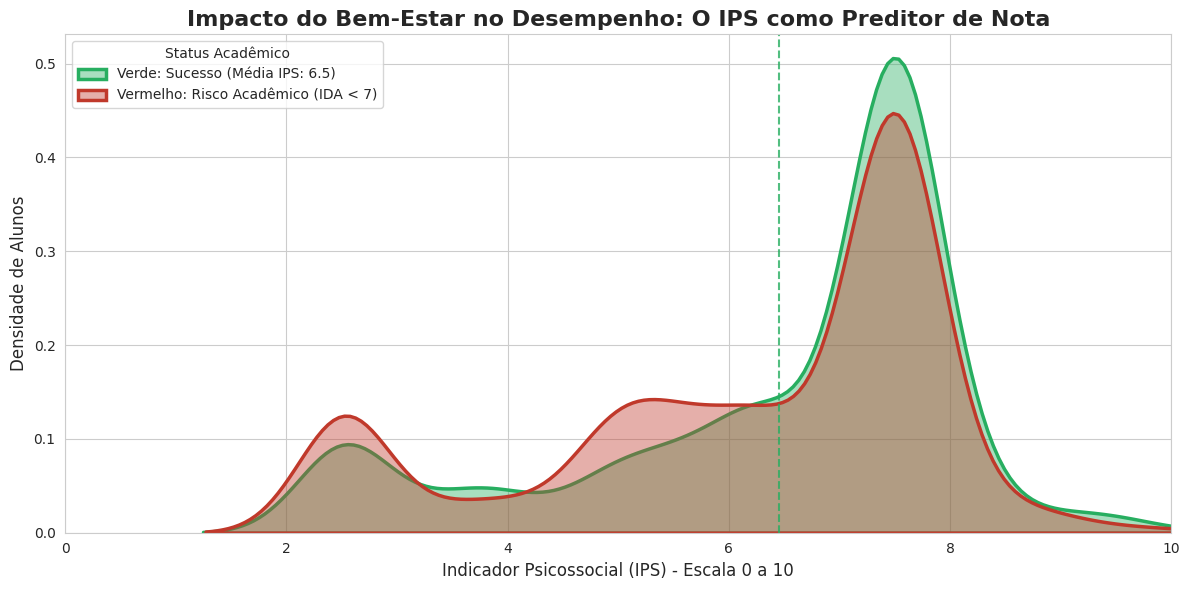

In [ ]:
def Aspectospsicossociais(df):
    df_copy = df.copy()

    c_ips = [c for c in df_copy.columns if c.upper() == 'IPS'][0]
    c_ida = [c for c in df_copy.columns if c.upper() == 'IDA'][0]

    df_copy['IPS'] = pd.to_numeric(df_copy[c_ips], errors='coerce')
    df_copy['IDA'] = pd.to_numeric(df_copy[c_ida], errors='coerce')
    df_copy = df_copy.dropna(subset=['IPS', 'IDA'])

    df_copy['Status'] = df_copy['IDA'].apply(
        lambda x: 'Sucesso (IDA >= 7)' if x >= 7 else 'Risco (IDA < 7)'
    )

    return df_copy

df_p5 = Aspectospsicossociais(df_completo)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

cores_map = {'Sucesso (IDA >= 7)': '#27ae60', 'Risco (IDA < 7)': '#c0392b'}

sns.kdeplot(
    data=df_p5,
    x='IPS',
    hue='Status',
    palette=cores_map,
    fill=True,
    alpha=0.4,
    linewidth=2.5,
    common_norm=False
)

mean_ips_sucesso = df_p5[df_p5['IDA'] >= 7]['IPS'].mean()
plt.axvline(mean_ips_sucesso, color='#27ae60', linestyle='--', alpha=0.8,
            label=f'Média IPS Sucesso: {mean_ips_sucesso:.1f}')

plt.title('Impacto do Bem-Estar no Desempenho: O IPS como Preditor de Nota', fontsize=16, fontweight='bold')
plt.xlabel('Indicador Psicossocial (IPS) - Escala 0 a 10', fontsize=12)
plt.ylabel('Densidade de Alunos', fontsize=12)

plt.legend(title='Status Acadêmico',
           labels=[f'Verde: Sucesso (Média IPS: {mean_ips_sucesso:.1f})',
                   'Vermelho: Risco Acadêmico (IDA < 7)'],
           loc='upper left')

plt.xlim(0, 10)
plt.tight_layout()

plt.show()

R5. Sim, a análise de densidade revela que o IPS atua como uma barreira de proteção.

A curva Verde (Sucesso) possui o maior pico e está concentrada no topo da régua de IPS (entre 7 e 9). Isso prova que o bem-estar psicossocial é a base que sustenta as notas altas.

O Alerta Vermelho: A curva Vermelha (Risco) ganha corpo em níveis de IPS onde a curva verde é quase inexistente (abaixo de 6). Isso indica que a queda no bem-estar é o padrão que antecede o baixo desempenho

#### **Q6. Aspectos psicopedagógicos (IPP):**
 As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

In [ ]:
df_ipp_ian = pd.concat(
    [df_2022[['ANO', 'IPP', 'IAN','DEFASAGEM']],
     df_2023[['ANO', 'IPP', 'IAN','DEFASAGEM']],
     df_2024[['ANO', 'IPP', 'IAN','DEFASAGEM']]],
    ignore_index=True
)

df_ipp_ian.head()

,ANO,IPP,IAN,DEFASAGEM
0,2022,8.174,5.0,-1
1,2022,7.894,10.0,0
2,2022,8.198,10.0,0
3,2022,5.554,10.0,0
4,2022,8.392,10.0,0


In [ ]:
print('Correlação entre IPP vs IAN/Defasagem: \n')
print(f'IPP vs IAN: {df_ipp_ian[['IPP','IAN','DEFASAGEM']].corr().iloc[0,1]:.3f}')
print(f'IPP vs Defasagem: {df_ipp_ian[['IPP','IAN','DEFASAGEM']].corr().iloc[0,2]:.3f}')
print('----------------------------------------------------------------------------------')

def classificar_defasagem(valor):
    if valor >= 0:
        return 'Adequado (IAN 10)'
    elif valor >= -2:
        return 'Defasagem Moderada (IAN 5)'
    else:
        return 'Defasagem Severa (IAN 2,5)'

df_ipp_ian['PERFIL_IAN'] = df_ipp_ian['DEFASAGEM'].apply(classificar_defasagem)

print('IPP médio em relação ao perfil de defasagem: \n')
print(f'Adequado (IAN 10): {df_ipp_ian.groupby('PERFIL_IAN')['IPP'].mean().iloc[0]:.3f}')
print(f'Defasagem Moderada (IAN 5): {df_ipp_ian.groupby('PERFIL_IAN')['IPP'].mean().iloc[1]:.3f}')
print(f'Defasagem Moderada (IAN 2,5): {df_ipp_ian.groupby('PERFIL_IAN')['IPP'].mean().iloc[2]:.3f}')


Correlação entre IPP vs IAN/Defasagem: 

IPP vs IAN: 0.179
IPP vs Defasagem: 0.239
----------------------------------------------------------------------------------
IPP médio em relação ao perfil de defasagem: 

Adequado (IAN 10): 7.417
Defasagem Moderada (IAN 5): 7.011
Defasagem Moderada (IAN 2,5): 6.671


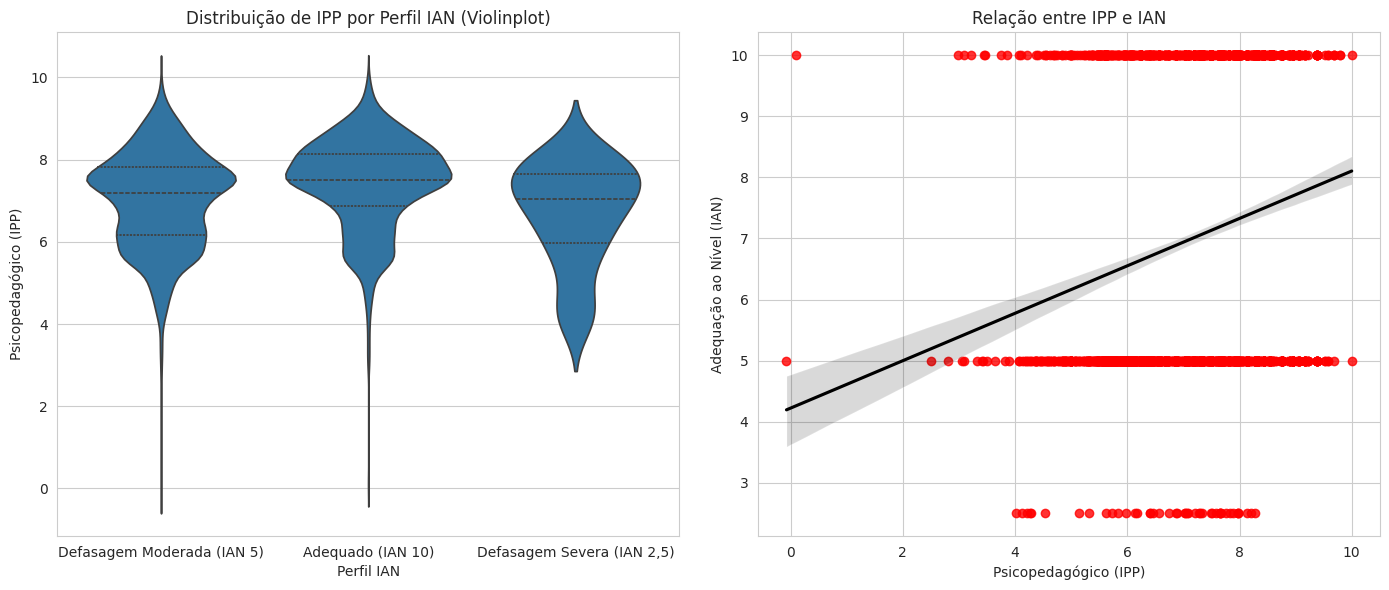

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=df_ipp_ian, x='PERFIL_IAN', y='IPP', ax=axes[0], inner='quartile')
axes[0].set_title("Distribuição de IPP por Perfil IAN (Violinplot)")
axes[0].set_xlabel("Perfil IAN")
axes[0].set_ylabel("Psicopedagógico (IPP)")

sns.regplot(data=df_ipp_ian, x='IPP', y='IAN', ax=axes[1], scatter_kws={'color': 'red'},  line_kws={'color': 'black'})
axes[1].set_title('Relação entre IPP e IAN')
axes[1].set_xlabel('Psicopedagógico (IPP)')
axes[1].set_ylabel('Adequação ao Nível (IAN)')

plt.tight_layout()
plt.show()



R6. Existe uma correlação positiva muito fraca (0.179) entre as avalições psicopedagógica (IPP) e o (IAN) o que indica que o IPP não é determinado pela defasagem.

O IPP **confirma** a tendência do IAN, mas não o contradiz. Através do gráfico de violino, podemos ver que os alunos com defesagem severa podem ter IPP alto sugerindo avaliações que o IAN não capta.

#### **Q7. Ponto de virada (IPV):**
Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

In [ ]:
df_completo[['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IAN', 'IPV']].corr()['IPV'].head(6).sort_values(ascending=False).round(3)

,IPV
IEG,0.558
IDA,0.557
IPP,0.521
IAN,0.149
IAA,0.063
IPS,-0.049


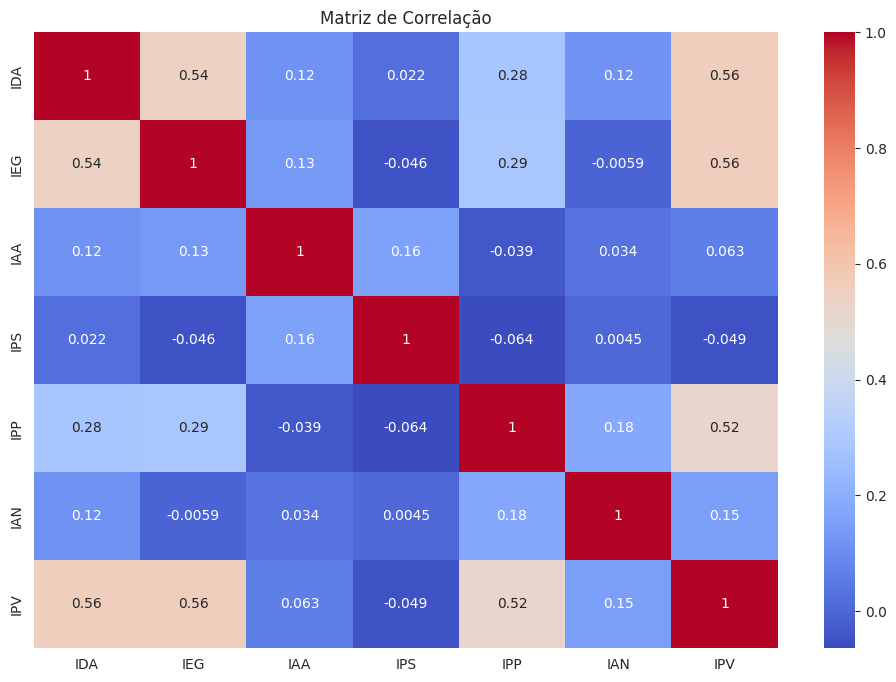

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_completo[['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IAN', 'IPV']].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

R7. Os comportamentos que mais influenciam o IPV ao longo do tempo são:
   1. IEG: 0.558
   2. IDA: 0.557
   3. IPP: 0.521

O engajamento (IEG) e o desempenho acadêmico (IDA) apresentam maiores correlações com o Ponto de Virada destacando-se como os principais influenciadores, reforçando que a participação ativa e a evolução acadêmica são determinantes para alcançar mudanças significativas. O fator psicopedagógico (IPP) apresenta uma boa correlação também, evidenciando sua importância central no processo.

#### **Q8. Multidimensionalidade dos indicadores:**
Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

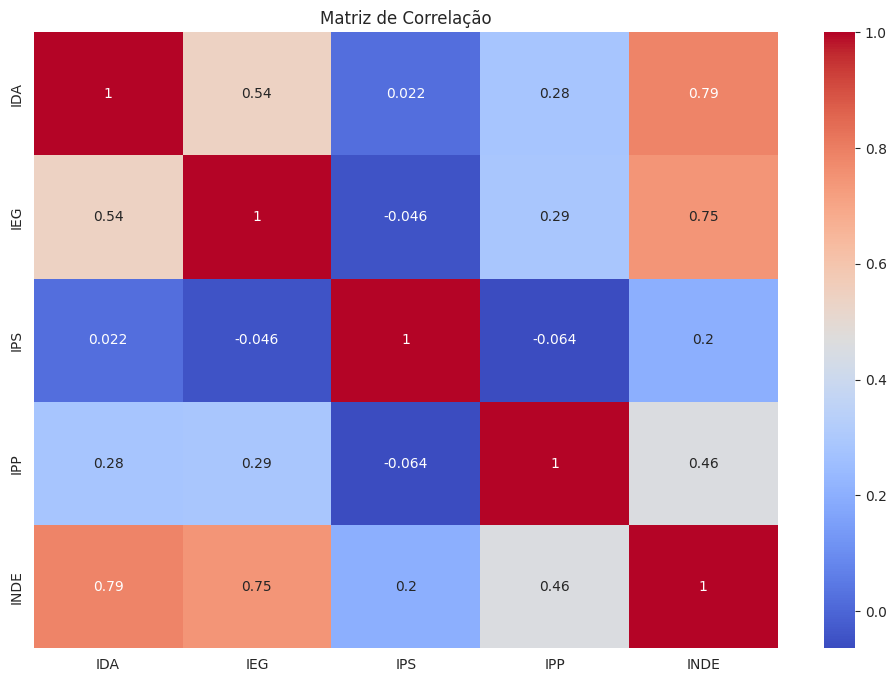

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_completo[['IDA', 'IEG', 'IPS', 'IPP', 'INDE']].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

Nota-se que os indicadores que mais tem correlação com o índice do desenvolvimento educacional (INDE) são o desempenho acadêmico (IDA) e o indicador de engajamento (IEG). Logo, podemos **supor** que são as combinações que mais elevam a nota global do aluno.

Isso, ocorre, pois a fórmula é constituída por pesos (ponderada):

$$INDE = IDA \times 0.2 + IEG \times 0.2 + IPS \times 0.1 + IPP \times 0.1$$

IDA e IEG tem o dobro do peso dos demais indicadores.

Porém, podemos medir o impacto dos indicadores no índice através do desvio padrão.

*Pouca variação = pouco impacto no índice (mesmo com peso alto)*.



In [ ]:
impacto_real = {
    'IDA': 0.2 * df_completo['IDA'].dropna().std(),
    'IEG': 0.2 * df_completo['IEG'].dropna().std(),
    'IPS': 0.1 * df_completo['IPS'].dropna().std(),
    'IPP': 0.1 * df_completo['IPP'].dropna().std()
}

df_impacto = pd.DataFrame(impacto_real, index=['Desvio Padrão'])
df_impacto

,IDA,IEG,IPS,IPP
Desvio Padrão,0.391327,0.392885,0.179249,0.11593


**R² - coeficiente de determinação**

Através do coeficiente, vamos poder medir o quanto da variação da variável dependente (INDE) é explicado pela aplicação da Regressão.

In [ ]:
indicadores = ['IDA','IEG','IPP','IPS']

for col in indicadores:
    df_ajustado = df_completo[[col, 'INDE']].dropna()

    X = df_ajustado[[col]]
    y = df_ajustado['INDE']

    model = LinearRegression()
    model.fit(X, y)

    print(f"R² - {col}:", model.score(X, y))

R² - IDA: 0.6167132258770684
R² - IEG: 0.5555174244682428
R² - IPP: 0.20777673311230338
R² - IPS: 0.0398473885228644


Como vimos anteriormente, os indicadores (IDA) e (IEG) elevam mais a nota global do aluno.

Vamos combinar os indicadores para avaliar, de fato, quais elevam mais a nota.

**Combinações**

In [ ]:
indicadores = ['IDA','IEG','IPP','IPS']

for c in combinations(indicadores, 2):

    df_ajustado = df_completo[list(c) + ['INDE']].dropna()

    X = df_ajustado[list(c)]
    y = df_ajustado['INDE']

    model = LinearRegression()
    model.fit(X, y)

    print(f"{"*"*150}\nIndicadores - {c}")
    print("Coeficientes:", dict(zip(X.columns, model.coef_)))
    print("R²:", model.score(X, y))

******************************************************************************************************************************************************
Indicadores - ('IDA', 'IEG')
Coeficientes: {'IDA': np.float64(0.27339105943421516), 'IEG': np.float64(0.28581799389227225)}
R²: 0.7606713814871786
******************************************************************************************************************************************************
Indicadores - ('IDA', 'IPP')
Coeficientes: {'IDA': np.float64(0.3615286223669597), 'IPP': np.float64(0.21849289432352784)}
R²: 0.6768099309414437
******************************************************************************************************************************************************
Indicadores - ('IDA', 'IPS')
Coeficientes: {'IDA': np.float64(0.3957978150746275), 'IPS': np.float64(0.10118389666778842)}
R²: 0.6498396930225534
************************************************************************************************************

R8. Como podemos avaliar acima, os indicadores de desempenho acadêmico (IDA) e de engajamento (IEG) explicam 76% da variação do ìndice de desenvolvimento educacional (INDE).

#### **Q9. Previsão de risco com Machine Learning:**

Quais padrões nos
indicadores permitem identificar alunos em risco antes de queda no desempenho
ou aumento da defasagem? Construa um modelo preditivo que mostre uma
probabilidade do aluno ou aluna entrar em risco de defasagem.


R9. Os indicadores mais fortes para identificar o risco dos alunos antecipadamente concentram-se no comportamento e no contexto do aluno, antes de refletirem no boletim:

Queda no Engajamento (IEG): A redução na participação, frequência e entrega de tarefas é o primeiro sintoma de desmotivação, ocorrendo muito antes de as notas caírem.

Alerta Psicossocial e Emocional (IPS e IAA): Índices baixos de suporte familiar/social ou baixa autoconfiança (autoavaliação) são gatilhos precoces e silenciosos para a desafagem.

Efeito Multiplicador da Defasagem: Alunos que já possuem atraso escolar (Defasagem < 0), começam a apresentar lentidão no Desempenho Acadêmico (IDA) e formam o padrão de altíssimo risco de piora no ano seguinte.

O padrão central é: O modelo preditivo matematicamente comprova que a queda do aluno começa na emoção e na atitude (IPS, IAA, IEG) antes de se consolidar como uma falha acadêmica (IDA ou INDE baixo).

------------------------------------------------------------------------------

O modelo preditivo está na seção de Modelagem preditiva.

Escohemos o modelo XGBoosting com os seguintes resultados:

Acurácia Treino: 81.9%
Acurácia Teste:  75.2%
Recall Risco:    86.4% = Alunos com Risco de defasagem.
Gap (Overfitting): 6.7%

#### **Q10. Efetividade do programa:**

Os indicadores mostram melhora
consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e
Topázio), confirmando o impacto real do programa?

In [ ]:
pedra_classe = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
kpi = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IAN', 'IPV', 'INDE']

df_completo.groupby('ANO')[kpi].mean().round(2)


,IDA,IEG,IAA,IPS,IPP,IAN,IPV,INDE
ANO,,,,,,,,
2022,6.09,7.89,8.27,6.90,6.28,6.42,7.25,7.04
2023,6.66,8.70,6.90,5.12,7.56,7.24,8.03,7.34
2024,6.35,7.63,8.54,6.83,7.55,7.61,7.35,7.40


In [ ]:
pedra_classe = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
kpi = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IAN', 'IPV', 'INDE']

indicadores_pedra = df_completo.groupby('PEDRA')[kpi].mean().round(2)
indicadores_pedra = indicadores_pedra.reindex(pedra_classe, level=0)
indicadores_pedra

,IDA,IEG,IAA,IPS,IPP,IAN,IPV,INDE
PEDRA,,,,,,,,
Quartzo,3.46,5.61,5.76,5.79,6.24,5.66,6.06,5.37
Ágata,5.26,7.59,7.23,5.99,6.86,6.08,7.03,6.59
Ametista,6.81,8.68,8.31,6.31,7.20,7.00,7.74,7.52
Topázio,8.18,9.38,9.02,6.84,7.89,8.62,8.46,8.44


In [ ]:
ano_pedra = df_completo.groupby(['ANO', 'PEDRA']).size().unstack(fill_value=0)
ano_pedra_pct = ano_pedra.div(ano_pedra.sum(axis=1), axis=0) * 100
ano_pedra_pct = ano_pedra_pct.reindex(pedra_classe, axis=1).round(2)
ano_pedra_pct

PEDRA,Quartzo,Ágata,Ametista,Topázio
ANO,,,,
2022,15.35,29.07,40.47,15.12
2023,7.73,26.42,40.92,24.92
2024,10.63,21.35,37.10,30.93


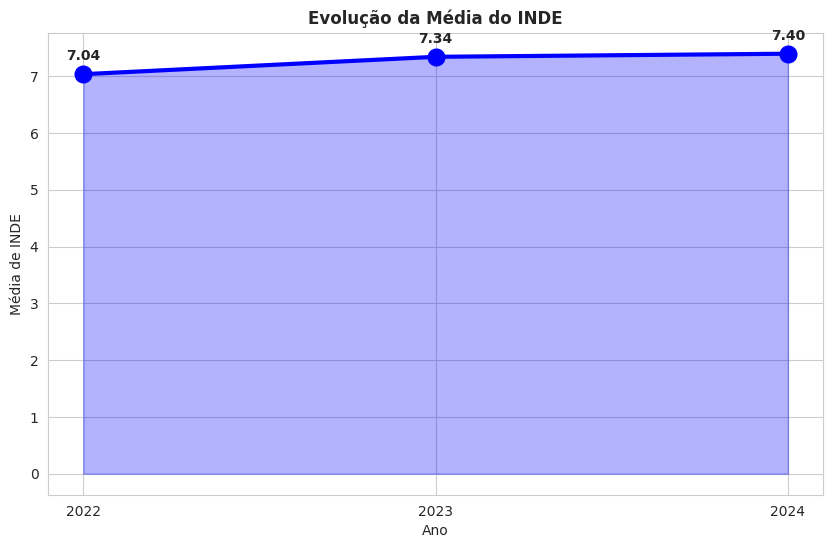

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
anos = df_completo.ANO.unique()
media_inde = df_completo.groupby('ANO')['INDE'].mean()

ax.plot(media_inde.index, media_inde.values, marker='o', linewidth=3, markersize=12, color='blue')
ax.fill_between(media_inde.index, media_inde.values, alpha=0.3, color='blue')
ax.set_title('Evolução da Média do INDE', fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Média de INDE')
ax.set_xticks(anos)

for x, y in zip(media_inde.index, media_inde.values):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontweight='bold')

plt.show();

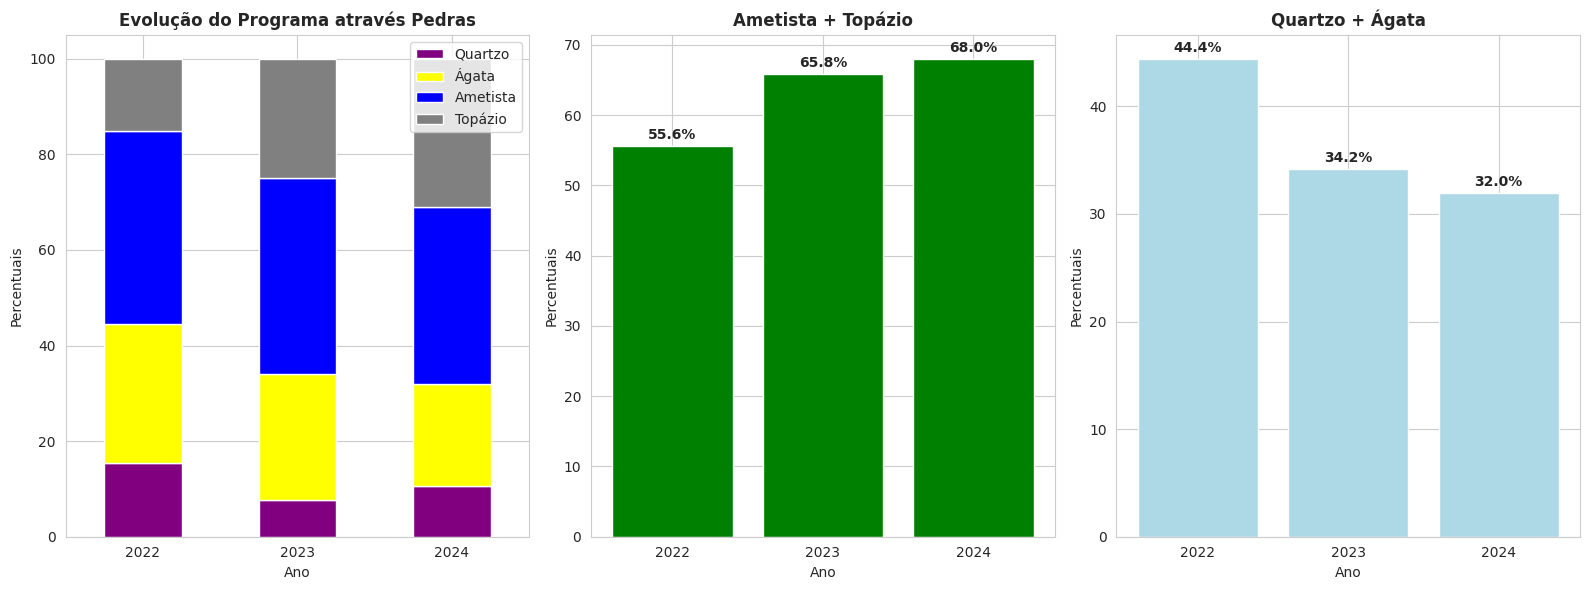

In [ ]:
repres_maior_pedra = ano_pedra_pct[['Ametista', 'Topázio']].sum(axis=1)
repres_menor_pedra = ano_pedra_pct[['Quartzo', 'Ágata']].sum(axis=1)
ano_pedra_pct
anos = ano_pedra_pct.index

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
ano_pedra_pct.plot(kind='bar', stacked=True, color = ['purple', 'yellow', 'blue', 'gray'], ax=axes[0])
axes[0].set_title('Evolução do Programa através Pedras', fontweight='bold')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Percentuais')
axes[0].legend()
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)


axes[1].bar(repres_maior_pedra.index, repres_maior_pedra.values, facecolor = 'green')
axes[1].set_title('Ametista + Topázio', fontweight='bold')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Percentuais')
axes[1].set_xticks(anos)
axes[1].set_xticklabels(anos)
for i, (x, y) in enumerate(zip(repres_maior_pedra.index, repres_maior_pedra.values)):
    axes[1].annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, 5), ha='center', fontweight='bold')

axes[2].bar(repres_menor_pedra.index, repres_menor_pedra.values, facecolor = 'lightblue')
axes[2].set_title('Quartzo + Ágata', fontweight='bold')
axes[2].set_xlabel('Ano')
axes[2].set_ylabel('Percentuais')
axes[2].set_xticks(anos)
axes[2].set_xticklabels(anos)
for i, (x, y) in enumerate(zip(repres_menor_pedra.index, repres_menor_pedra.values)):
    axes[2].annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, 5), ha='center', fontweight='bold')



plt.tight_layout()
plt.show();

R10. Podemos analisar através da exploração dos dados acima e entender que sim. Os indicadores mostram melhora consistente ao longo do ciclo confirmando o impacto real do programa.

1. A média do INDE melhorou saindo de 7,04 em 2022 e indo para 7,34 em 2023 e por fim chegando a 7,40 em 2024. Isso demonstra uma evolução no índice.
2. As pedras que carregam as melhores performances dos alunos tiveram um crescimento de 12,4p.p.de 2022 para 2024. O que mostra que é eficiente o processo como um todo realizado pela Passos Mágicos.
3. Através dos gráficos é possível enxergar que os alunos estão performando melhor ao longo dos anos e que o programa, sim traz um impacto real e também justificado pela cultura dos dados, traz impacto na vida dos alunos.

#### **Q11. Insights e criatividade:**

Você pode adicionar mais insights e pontos
de vista não abordados nas perguntas, utilize a criatividade e a análise dos dados
para trazer sugestões para a Passos Mágicos.

R11. A Anatomia da Alta Performance

Sabemos que o programa é efetivo e cresce ano a ano (como visto na Q10). Mas o que separa os alunos de base (Quartzo e Ágata) da elite acadêmica da Passos Mágicos (Ametista e Topázio)?
Para descobrir onde a ONG deve focar seus esforços, criamos uma análise comparativa dos 5 pilares do INDE. Nosso objetivo é responder: **Qual é o indicador que mais impulsiona um aluno para o topo?**

In [ ]:
df_anatomia = df_completo.copy()
df_anatomia['PERFIL_DESEMPENHO'] = np.where(
    df_anatomia['PEDRA'].str.upper().isin(['AMETISTA', 'TOPÁZIO', 'TOPAZIO']),
    'Elite (Ametista / Topázio)',
    'Base (Quartzo / Ágata)'
)

kpis = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP']
medias_perfil = df_anatomia.groupby('PERFIL_DESEMPENHO')[kpis].mean().T

medias_perfil['GAP'] = medias_perfil['Elite (Ametista / Topázio)'] - medias_perfil['Base (Quartzo / Ágata)']
medias_perfil = medias_perfil.sort_values(by='GAP', ascending=False)

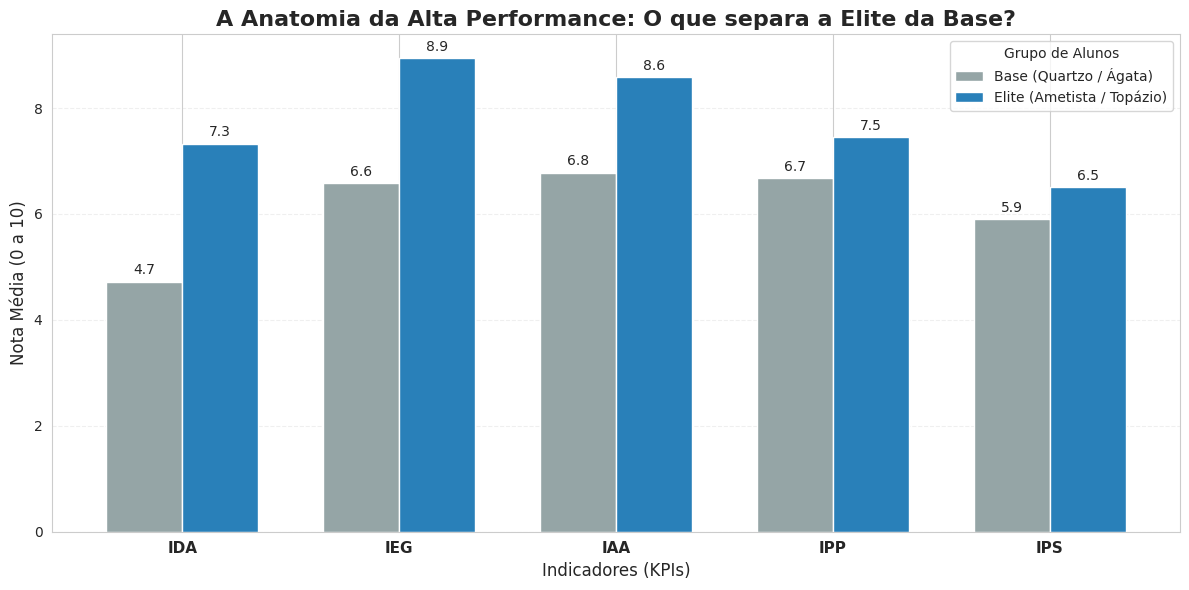

In [ ]:
# GRÁFICO: A ANATOMIA DA ALTA PERFORMANCE

fig, ax = plt.subplots(figsize=(12, 6))

medias_perfil[['Base (Quartzo / Ágata)', 'Elite (Ametista / Topázio)']].plot(
    kind='bar',
    color=['#95a5a6', '#2980b9'],
    ax=ax,
    width=0.7
)

plt.title('A Anatomia da Alta Performance: O que separa a Elite da Base?', fontsize=16, fontweight='bold')
plt.ylabel('Nota Média (0 a 10)', fontsize=12)
plt.xlabel('Indicadores (KPIs)', fontsize=12)
plt.xticks(rotation=0, fontsize=11, fontweight='bold')
plt.legend(title='Grupo de Alunos', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

 Pelo gráfico, fica claro que existe uma diferença grande entre os alunos da Base (Quartzo/Ágata) e da Elite (Ametista/Topázio), principalmente no Indicador de Aprendizagem (IDA) e no Indicador de Engajamento (IEG).

Por outro lado, essa diferença é bem pequena no Indicador Psicopedagógico (IPP) e no Indicador Psicossocial (IPS) — e isso é uma ótima notícia. Mostra que a Passos Mágicos oferece suporte emocional e estrutural de forma equilibrada. Ou seja, os alunos da base não estão ficando para trás por falta de apoio psicológico ou estrutura. A base está bem construída para todos.

In [ ]:
# Exibir tabela rápida de GAP

print("O TAMANHO DO DEGRAU (GAP ENTRE ELITE E BASE):")
display(medias_perfil[['GAP']].style.format("{:.2f} pontos").background_gradient(cmap='Greens'))

O TAMANHO DO DEGRAU (GAP ENTRE ELITE E BASE):


PERFIL_DESEMPENHO,GAP
IDA,2.61 pontos
IEG,2.36 pontos
IAA,1.80 pontos
IPP,0.79 pontos
IPS,0.60 pontos


A tabela deixa ainda mais evidente a distância entre Base e Elite.

Se o suporte é o mesmo, então o que faz um aluno chegar à Elite? O comportamento.

O IEG (Engajamento) dá um salto de 2,36 pontos — sai de 6,6 na base para 8,9 na elite. Junto com ele, o IAA (Autoavaliação) cresce 1,80 pontos. Isso mostra que os alunos que participam mais, entregam atividades e acreditam no próprio potencial tendem a evoluir dentro do programa. O engajamento acaba sendo o motor que puxa o desempenho para cima.

O maior gap aparece no IDA (Desempenho Acadêmico), com 2,61 pontos de diferença. Mas olhando para os dados comportamentais (IEG e IAA), dá para entender que esse resultado não é apenas “facilidade” ou “inteligência natural”. O IDA mais alto da elite (7,3) parece ser consequência de um engajamento constante e de uma autoconfiança maior. O desempenho é resultado do processo.

**Decisão de Negócio e Conexão com Machine Learning**

Na prática, a ONG não precisa mudar o suporte psicológico — ele já funciona e está equilibrado. O foco deve estar em recuperar o Engajamento (IEG) e fortalecer a Autoconfiança (IAA) dos alunos da base. Quando o aluno participa e acredita em si, o desempenho acadêmico tende a melhorar como consequência.

E é exatamente por isso que faz sentido usar um modelo preditivo.

Se o engajamento é o principal motor da evolução, não dá para esperar o fim do ano para perceber que ele caiu. O modelo de Inteligência Artificial entra para acompanhar essas variações ao longo do tempo e identificar sinais de alerta antes que o aluno perca desempenho ou deixe de evoluir dentro do programa.

Assim, a intervenção deixa de ser reativa e passa a ser preventiva.

## **Modelagem preditiva**

Q9. Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

In [ ]:
# Cria uma cópia para não alterar o original sem querer

df_modelagem = df_completo.copy()

# Selecionar apenas colunas essenciais para a criação do alvo

df_modelagem = df_modelagem.sort_values(by=['RA', 'ANO'])

print(f"Total de registros originais: {len(df_modelagem)}")

# A ideia é colar ao lado de cada aluno a 'DEFASAGEM' que ele teve no ano seguinte.

# Criamos um dataframe auxiliar apenas com o "Futuro"

df_futuro = df_modelagem[['RA', 'ANO', 'DEFASAGEM']].copy()

# Subtraímos 1 do ano. Assim, os dados de 2023 viram '2022' para dar match.

df_futuro['ANO_JOIN'] = df_futuro['ANO'] - 1

# Fazemos o merge (cruzamento)

# Inner Join: Só mantemos alunos que temos o histórico contínuo (Ano X e Ano X+1)

df_treino = pd.merge(
    df_modelagem,
    df_futuro[['RA', 'ANO_JOIN', 'DEFASAGEM']],
    left_on=['RA', 'ANO'],
    right_on=['RA', 'ANO_JOIN'],
    how='inner',
    suffixes=('', '_PROXIMO')
)

#  Definindo a Lógica do Risco (Coluna Alvo para o ML)

# Com Risco = 1  | sem Risco = 0

def definir_alvo(row):
    defas_atual = row['DEFASAGEM']
    defas_prox = row['DEFASAGEM_PROXIMO'] # Corrected column name to be all caps

    # Critério 1: Piorou a defasagem? (Ex: de -1 para -2, ou 0 para -1)

    piorou = defas_prox < defas_atual

    # Critério 2: Manteve-se em situação crítica?

    # Se ele já estava ruim e continuou ruim (mesmo sem piorar), ainda está com risco.

    critico_persistente = (defas_prox <= -2)

    if piorou or critico_persistente:
        return 1 # COM RISCO
    else:
        return 0 # SEM RISCO

df_treino['ALVO'] = df_treino.apply(definir_alvo, axis=1)

# Remover colunas auxiliares usadas apenas para o cálculo

df_treino = df_treino.drop(columns=['ANO_JOIN', 'DEFASAGEM_PROXIMO'])

# Visualizar o Resultado

print("-" * 30)
print(f"Tamanho do Dataset de Treino Final: {len(df_treino)} linhas")
print("-" * 30)
print("Distribuição das Classes (Balanceamento):")
print(df_treino['ALVO'].value_counts(normalize=True).map('{:.1%}'.format))
print("-" * 30)

# Mostrar exemplos

print("\nExemplo de Alunos com Risco (ALVO = 1):")
display(df_treino[df_treino['ALVO'] == 1][['RA', 'ANO', 'DEFASAGEM', 'ALVO']].head(3))

print("\nExemplo de Alunos sem Risco (ALVO = 0):")
display(df_treino[df_treino['ALVO'] == 0][['RA', 'ANO', 'DEFASAGEM', 'ALVO']].head(3))

Total de registros originais: 2992
------------------------------
Tamanho do Dataset de Treino Final: 1352 linhas
------------------------------
Distribuição das Classes (Balanceamento):
ALVO
0    75.9%
1    24.1%
Name: proportion, dtype: object
------------------------------

Exemplo de Alunos com Risco (ALVO = 1):


,RA,ANO,DEFASAGEM,ALVO
5,RA-1003,2023,0,1
6,RA-1004,2023,0,1
7,RA-1006,2023,0,1



Exemplo de Alunos sem Risco (ALVO = 0):


,RA,ANO,DEFASAGEM,ALVO
0,RA-1,2022,-1,0
1,RA-1,2023,0,0
2,RA-1000,2023,0,0


In [ ]:
# Lógica: Cruzar Ano X com Ano X+1 para saber quem piorou

df_model = df_completo.copy()
df_futuro = df_model[['RA', 'ANO', 'DEFASAGEM']].copy()
df_futuro['ANO_JOIN'] = df_futuro['ANO'] - 1

df_treino = pd.merge(
    df_model,
    df_futuro[['RA', 'ANO_JOIN', 'DEFASAGEM']],
    left_on=['RA', 'ANO'],
    right_on=['RA', 'ANO_JOIN'],
    how='inner',
    suffixes=('', '_PROXIMO')
)

# Definição do Alvo (Target): 1 = Risco, 0 = Sem Risco

def definir_alvo(row):
    piorou = row['DEFASAGEM_PROXIMO'] < row['DEFASAGEM'] # Ex: -1 para -2
    critico = row['DEFASAGEM_PROXIMO'] <= -2 # Já está muito atrasado
    return 1 if (piorou or critico) else 0

df_treino['ALVO'] = df_treino.apply(definir_alvo, axis=1)

#  PREPARAÇÃO PARA O MACHINE LEARNING

features = ['FASE', 'GENERO', 'INDE', 'PEDRA', 'IAA', 'IEG', 'IPS', 'IDA', 'DEFASAGEM']

# Limpeza de Nulos (Removemos linhas incompletas para garantir qualidade)

df_ml = df_treino[features + ['ALVO']].dropna().copy()

# Encoding (Transformar texto em número para o modelo entender)

encoders = {}
for col in ['FASE', 'PEDRA', 'GENERO']:
    le = LabelEncoder()

    # Treinamos o encoder com TODAS as opções possíveis de todos os anos

    le.fit(df_completo[col].astype(str).unique())
    df_ml[col] = le.transform(df_ml[col].astype(str))
    encoders[col] = le

### Random Forest

In [ ]:
# Treinameto do modelo Random Forest

X = df_ml[features]
y = df_ml['ALVO']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_otimizado = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=8,
    class_weight='balanced_subsample',
    random_state=42
)

rf_otimizado.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=4,
                       min_samples_leaf=8, n_estimators=300, random_state=42)

### XGBoost

In [ ]:
# Treinameto do modelo XGBoost

ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# Configurar a Grade de Testes

param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_child_weight': [5, 7],
    'scale_pos_weight': [ratio],
    'gamma': [0.5, 1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

# Rodar a Busca

xgb_model = xgb.XGBClassifier(random_state=42, scale_pos_weight=3.18, eval_metric='logloss', use_label_encoder=False)

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='recall', # O objetivo é encontrar alunos com risco
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 576 candidates, totalling 1728 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[23:20:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8], 'gamma': [0.5, 1],
                         'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [2, 3, 5], 'min_child_weight': [5, 7],
                         'n_estimators': [100, 200, 300, 400],
                         'scale_pos_weight': [np.float64(3.128)],
                         'subsample': [0.7, 0.8]},
             scoring='recall', verbose=1)

### **Avaliação**

### Random Forest

In [ ]:
# Avaliação do Modelo Random Forest

y_pred = rf_otimizado.predict(X_test)
acc_train = accuracy_score(y_train, rf_otimizado.predict(X_train))
acc_test = accuracy_score(y_test, rf_otimizado.predict(X_test))

print(f"RESULTADO DO MODELO RANDOM FOREST\n")
print(f"Relatório de Classificação:\n, {classification_report(y_test, y_pred)}\n")

print(f"Acurácia Treino: {acc_train:.2%}")
print(f"Acurácia Teste:  {acc_test:.2%}")
print(f"Recall Risco:    {recall_score(y_test, y_pred):.1%}")
print(f"Gap (Overfitting): {acc_train - acc_test:.2%}")

RESULTADO DO MODELO RANDOM FOREST

Relatório de Classificação:
,               precision    recall  f1-score   support

           0       0.86      0.81      0.83       192
           1       0.53      0.61      0.56        66

    accuracy                           0.76       258
   macro avg       0.69      0.71      0.70       258
weighted avg       0.77      0.76      0.76       258


Acurácia Treino: 80.43%
Acurácia Teste:  75.97%
Recall Risco:    60.6%
Gap (Overfitting): 4.46%


### XGBoost

In [ ]:
# Avaliação do Modelo XGBoost

best_xgb = grid_xgb.best_estimator_
previsoes_ajustadas = best_xgb.predict(X_test)
train_pred_xgb = best_xgb.predict(X_train)

print(f"RESULTADO DO MODELO XGBOOST\n")

# Pega as probabilidades brutas (coluna 1 é a probabilidade de Risco)
probabilidades = grid_xgb.predict_proba(X_test)[:, 1]

novo_corte = 0.41

# Cria as previsões baseadas no novo corte
previsoes_ajustadas = (probabilidades >= novo_corte).astype(int)

print(f"RESULTADO COM CORTE DE {novo_corte*100}%:")
print(classification_report(y_test, previsoes_ajustadas))

print(f"Acurácia Treino: {accuracy_score(y_train, train_pred_xgb):.1%}")
print(f"Acurácia Teste:  {accuracy_score(y_test, previsoes_ajustadas):.1%}")
print(f"Recall Risco:    {recall_score(y_test, previsoes_ajustadas):.1%}")
print(f"Gap (Overfitting): {accuracy_score(y_train, train_pred_xgb) - accuracy_score(y_test, previsoes_ajustadas):.1%}")

RESULTADO DO MODELO XGBOOST

RESULTADO COM CORTE DE 41.0%:
              precision    recall  f1-score   support

           0       0.94      0.71      0.81       192
           1       0.51      0.86      0.64        66

    accuracy                           0.75       258
   macro avg       0.72      0.79      0.73       258
weighted avg       0.83      0.75      0.77       258

Acurácia Treino: 81.9%
Acurácia Teste:  75.2%
Recall Risco:    86.4%
Gap (Overfitting): 6.7%


### **Deploy**

In [ ]:
df_completo_2024 = df_completo[df_completo['ANO'] == 2024].copy()

# Salvar CSV

df_completo_2024.to_csv('Previsao_Risco_2025.csv', index=False)
print("\n CSV salvo: Previsao_Risco_2025.csv")

# Salvar Modelo e Encoders

joblib.dump(best_xgb, 'modelo_xgboost.pkl')
joblib.dump(encoders, 'encoders.pkl')
print(" Modelo salvo: modelo_xgboost.pkl")
print(" Encoders salvos: encoders.pkl")


 CSV salvo: Previsao_Risco_2025.csv
 Modelo salvo: modelo_xgboost.pkl
 Encoders salvos: encoders.pkl
